# Problem Statement

## Objective  
Training a machine learning model to accurately predict the MBTI personality type from a social media post.

## Dataset  
This project leverages the **Kaggle MBTI Dataset**, which contains:  
- **6506 Records**  
- Each person’s ** social media posts**  
- Their **self‑reported MBTI personality type**
  
URL `https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_train.csv`

## Approach  
The goal is to build **Natural Language Processing (NLP) models** that learn linguistic patterns associated with each personality dimension. By analyzing text features, the models aim to uncover correlations between writing style and MBTI classification.


## Step 1: Setup & Imports
Concept: NLP projects need a different set of libraries compared to the regression and classification projects you have already built. Alongside the usual data and ML libraries you now need text processing tools.

**Why necessary**:

nltk provides text cleaning utilities — stopwords, stemming, tokenization
re handles pattern matching for cleaning raw social media text
wordcloud creates visual representations of common words
sklearn handles feature extraction (TF-IDF) and all classifiers
collections helps count word and type frequencies

In [2]:
!pip install wordcloud

In [6]:
import pandas as pd
import numpy as np
import re
import collections
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import joblib
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Libraries loaded successfully")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tim\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tim\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Tim\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries loaded successfully


In [3]:
# The 4 binary dimensions we will predict
dimensions = {
    'Mind':    ('I', 'E'),   # Introvert vs Extrovert
    'Energy':  ('N', 'S'),   # Intuitive vs Sensing
    'Nature':  ('T', 'F'),   # Thinking vs Feeling
    'Tactics': ('J', 'P')    # Judging vs Perceiving
}

print("Personality dimensions to predict:")
for dim, (a, b) in dimensions.items():
    print(f"  {dim}: {a} vs {b}")

Personality dimensions to predict:
  Mind: I vs E
  Energy: N vs S
  Nature: T vs F
  Tactics: J vs P


## Step 2: Load & Explore the Data (EDA)

### Concept  
Before any text processing or modeling, it’s essential to understand the raw data. The MBTI dataset is unique — each row represents one person, and their last 50 social media posts are concatenated into a single string separated by `|||`.

### Why Necessary  
- **Understand raw text structure** → Determines how you clean and tokenize the data.  
- **Check class distribution** → Reveals imbalance, which is critical for NLP classification tasks.  
- **Inspect sample posts** → Helps identify noise to remove (e.g., URLs, special characters, MBTI type mentions).  
- **Analyze word and character counts** → Informs TF‑IDF and other vectorization settings later in the pipeline.


In [8]:
# Load dataset — update path to match your file location
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_train.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (6506, 2)

Column names: ['type', 'posts']

First 3 rows:


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1ro...
1,ENTP,'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the sam...
2,INTP,"'Good one _____ https://www.youtube.com/watch?v=fHiGbolFFGw|||Of course, to which I say I kno..."


In [9]:
print("Dataset Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique personality types:", df['type'].nunique())
print("All types:", sorted(df['type'].unique()))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6506 entries, 0 to 6505
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    6506 non-null   object
 1   posts   6506 non-null   object
dtypes: object(2)
memory usage: 101.8+ KB
None

Missing values:
type     0
posts    0
dtype: int64

Unique personality types: 16
All types: ['ENFJ', 'ENFP', 'ENTJ', 'ENTP', 'ESFJ', 'ESFP', 'ESTJ', 'ESTP', 'INFJ', 'INFP', 'INTJ', 'INTP', 'ISFJ', 'ISFP', 'ISTJ', 'ISTP']


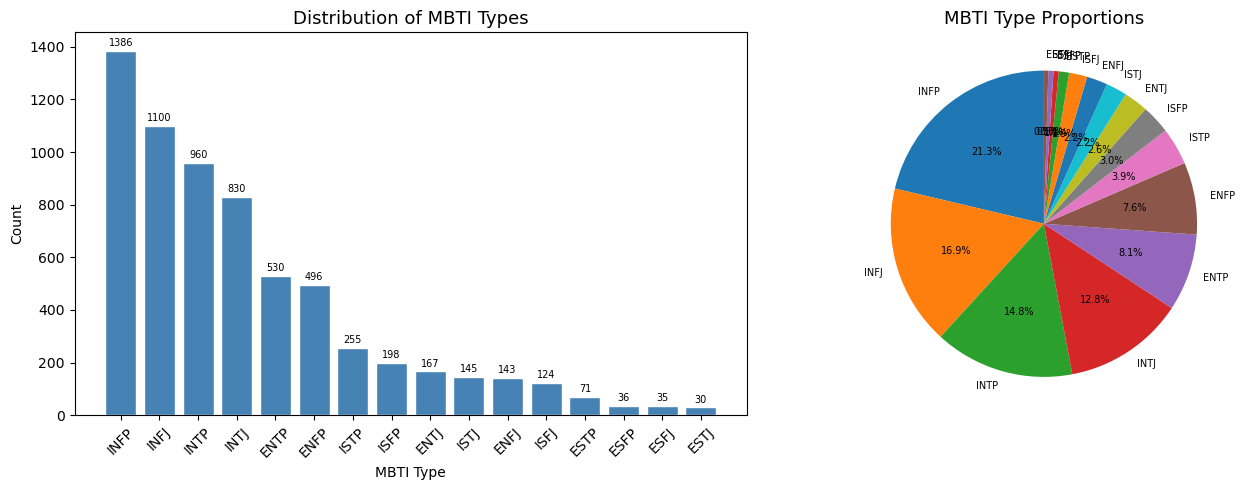


Type distribution:
type
INFP    1386
INFJ    1100
INTP     960
INTJ     830
ENTP     530
ENFP     496
ISTP     255
ISFP     198
ENTJ     167
ISTJ     145
ENFJ     143
ISFJ     124
ESTP      71
ESFP      36
ESFJ      35
ESTJ      30
Name: count, dtype: int64


In [10]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(14, 5))

# Count plot
plt.subplot(1, 2, 1)
bars = plt.bar(type_counts.index, type_counts.values, color='steelblue', edgecolor='white')
plt.title("Distribution of MBTI Types", fontsize=13)
plt.xlabel("MBTI Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Add value labels
for bar, val in zip(bars, type_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=7)

# Percentage plot
plt.subplot(1, 2, 2)
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 7}
)
plt.title("MBTI Type Proportions", fontsize=13)

plt.tight_layout()
plt.show()

print("\nType distribution:")
print(type_counts)

**Observation** 

MBTI data is heavily imbalanced. INFP and INFJ types dominate the Personality forum.

In [11]:
# Extract each dimension as a binary label
df['Mind']    = df['type'].apply(lambda x: x[0])  # I or E
df['Energy']  = df['type'].apply(lambda x: x[1])  # N or S
df['Nature']  = df['type'].apply(lambda x: x[2])  # T or F
df['Tactics'] = df['type'].apply(lambda x: x[3])  # J or P

print("Dimension distributions:")
for dim in ['Mind', 'Energy', 'Nature', 'Tactics']:
    print(f"\n{dim}:")
    print(df[dim].value_counts())

Dimension distributions:

Mind:
Mind
I    4998
E    1508
Name: count, dtype: int64

Energy:
Energy
N    5612
S     894
Name: count, dtype: int64

Nature:
Nature
F    3518
T    2988
Name: count, dtype: int64

Tactics:
Tactics
P    3932
J    2574
Name: count, dtype: int64


### Visualize the dimensions

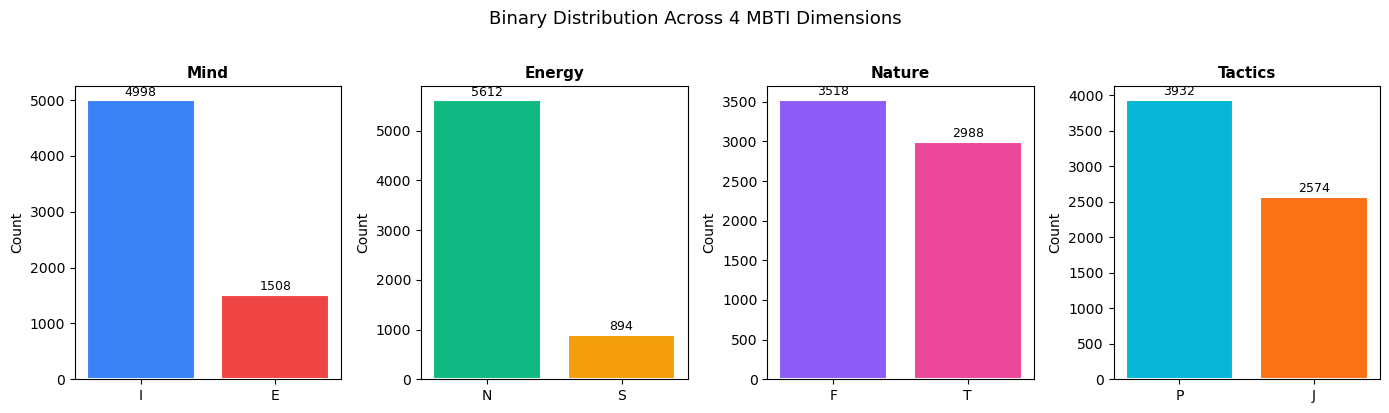

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

colors = [['#3b82f6', '#ef4444'],
          ['#10b981', '#f59e0b'],
          ['#8b5cf6', '#ec4899'],
          ['#06b6d4', '#f97316']]

for idx, dim in enumerate(['Mind', 'Energy', 'Nature', 'Tactics']):
    counts = df[dim].value_counts()
    axes[idx].bar(counts.index, counts.values,
                  color=colors[idx], edgecolor='white', linewidth=1.5)
    axes[idx].set_title(f"{dim}", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel("Count")

    for i, (label, val) in enumerate(counts.items()):
        axes[idx].text(i, val + 30, str(val),
                      ha='center', va='bottom', fontsize=9)

plt.suptitle("Binary Distribution Across 4 MBTI Dimensions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Explore raw post structure

In [13]:
# Look at a raw post sample
sample_posts = df['posts'].iloc[0]

print("Raw posts sample (first 500 chars):")
print(sample_posts[:500])
print("\n...")
print("\nPosts are separated by: |||")
print("Number of posts in first row:", len(sample_posts.split('|||')))

Raw posts sample (first 500 chars):
'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8   http://www.youtube.com/watch?v=u8ejam5DP3E  On repeat for most of today.|||May the PerC Experience immerse you.|||The last thin

...

Posts are separated by: |||
Number of posts in first row: 50


### Text length analysis

In [14]:
# Add text length features
df['post_length'] = df['posts'].apply(len)
df['word_count']  = df['posts'].apply(lambda x: len(x.split()))
df['post_count']  = df['posts'].apply(lambda x: len(x.split('|||')))

print("Text Statistics:")
print(df[['post_length', 'word_count', 'post_count']].describe().round(2))

Text Statistics:
       post_length  word_count  post_count
count      6506.00     6506.00     6506.00
mean       7209.57     1221.92       48.65
std        1632.82      315.51        5.70
min          57.00        4.00        1.00
25%        6292.25     1041.00       50.00
50%        7497.00     1276.00       50.00
75%        8410.75     1454.00       50.00
max       10090.00     1881.00       83.00


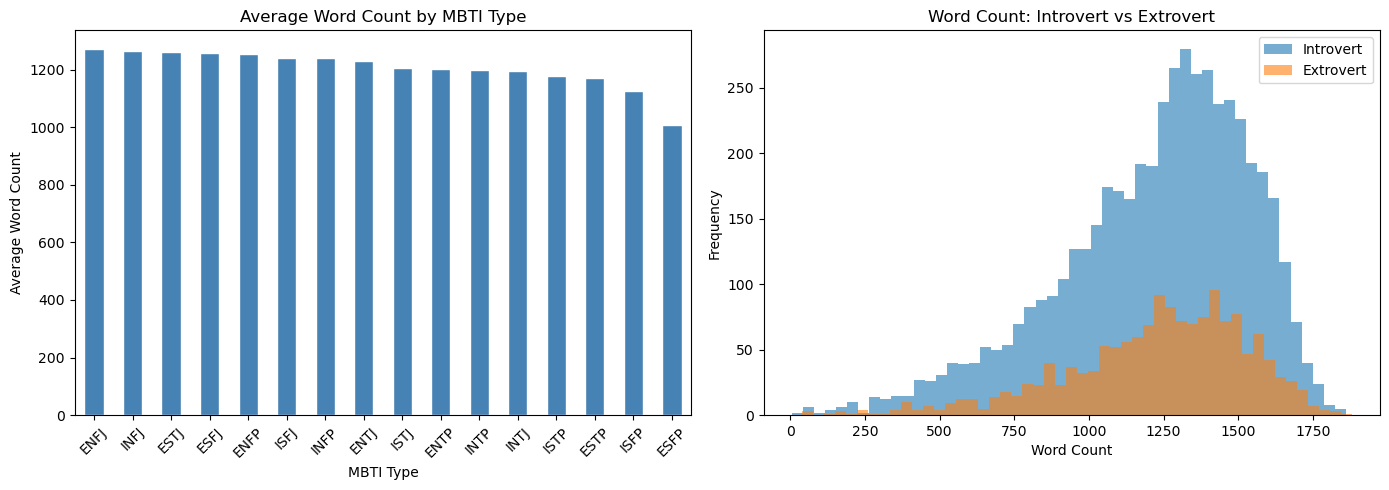

In [15]:
# Visualize text length by personality type
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df.groupby('type')['word_count'].mean().sort_values(ascending=False).plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title("Average Word Count by MBTI Type")
plt.xlabel("MBTI Type")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
for dim_val in ['I', 'E']:
    subset = df[df['Mind'] == dim_val]['word_count']
    plt.hist(subset, bins=50, alpha=0.6,
             label=f"{'Introvert' if dim_val == 'I' else 'Extrovert'}")

plt.title("Word Count: Introvert vs Extrovert")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

**What I've learnt**:

MBTI data is naturally multi-label. One type string encodes 4 separate binary labels simultaneously. Extracting each dimension with x[0], x[1], x[2], x[3] is a clean and elegant approach

Class imbalance is a defining characteristic of this dataset — N types heavily outnumber S types because personality forums self-select for certain types
Raw social media text is very noisy — you can already see URLs, ||| separators, and MBTI type mentions in the raw samples which all need cleaning

## Step 3: Text Preprocessing

### Concept  
Raw social media text is extremely noisy. Before any model can learn from it, you need to transform messy human writing into clean, standardized tokens. This is the most important step in any NLP project — *garbage in, garbage out* applies more here than anywhere else in data science.

### Why Necessary  
- **Remove noise** → URLs, numbers, and special characters add clutter without meaningful signal.  
- **Prevent data leakage** → MBTI type mentions (e.g., *"as an INFP I feel..."*) would let the model cheat by spotting type references instead of learning linguistic patterns.  
- **Filter stopwords** → Common words like *"the"*, *"a"*, *"is"* appear in every post regardless of personality, diluting the signal.  
- **Apply lemmatization** → Reduces words to their root form (*"running"*, *"runs"*, *"ran"* → *"run"*), shrinking vocabulary size and improving generalization.


In [17]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# MBTI types to remove — critical to prevent leakage
mbti_types = [
    'infp', 'infj', 'intp', 'intj',
    'entp', 'enfp', 'istp', 'isfp',
    'entj', 'istj', 'enfj', 'isfj',
    'estp', 'esfp', 'estj', 'esfj',
    'intj', 'infp'
]

def clean_text(text):
    """
    Full NLP preprocessing pipeline for MBTI posts.
    Steps: lowercase → remove URLs → remove MBTI types →
           remove special chars → remove numbers →
           tokenize → remove stopwords → lemmatize → rejoin
    """
    # 1. Lowercase everything
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 3. Remove MBTI type mentions — prevents leakage
    for mbti in mbti_types:
        text = re.sub(mbti, '', text)

    # 4. Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenize
    tokens = word_tokenize(text)

    # 7. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 8. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 9. Rejoin into a single string
    return ' '.join(tokens)

print("Cleaning function defined")

Cleaning function defined


In [18]:
# Clean the dataset
df['cleaned_posts'] = df['posts'].apply(clean_text)

print("Cleaning complete!")
print(f"\nOriginal posts sample:\n{df['posts'].iloc[0][:300]}")
print(f"\nCleaned posts sample:\n{df['cleaned_posts'].iloc[0][:300]}")

Cleaning complete!

Original posts sample:
'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  pranks|||What has been the most life-changing

Cleaned posts sample:
moment sportscenter top ten play prankswhat lifechanging experience life repeat todaymay perc experience immerse youthe last thing friend posted facebook committing suicide next day rest peace sorry hear distress natural relationship perfection time every moment existence try figure hard time time g


In [19]:
# Compare before and after
df['original_word_count'] = df['posts'].apply(lambda x: len(x.split()))
df['cleaned_word_count']  = df['cleaned_posts'].apply(lambda x: len(x.split()))

print("Word count comparison:")
print(f"  Original avg words: {df['original_word_count'].mean():.0f}")
print(f"  Cleaned avg words:  {df['cleaned_word_count'].mean():.0f}")
print(f"  Reduction:          {((df['original_word_count'].mean() - df['cleaned_word_count'].mean()) / df['original_word_count'].mean() * 100):.1f}%")

# Check no empty posts after cleaning
empty_posts = df['cleaned_posts'].apply(lambda x: len(x.strip()) == 0).sum()
print(f"\nEmpty posts after cleaning: {empty_posts}")

Word count comparison:
  Original avg words: 1222
  Cleaned avg words:  590
  Reduction:          51.7%

Empty posts after cleaning: 1


### Visualize most common words overall

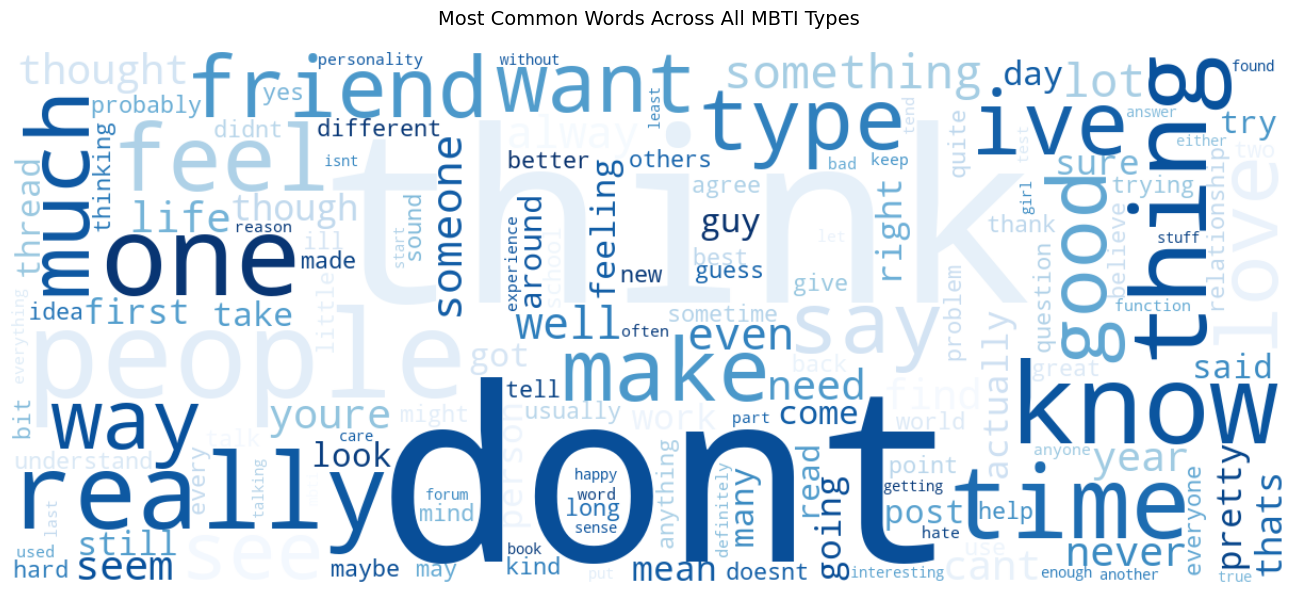

In [20]:
# Combine all cleaned posts
all_text = ' '.join(df['cleaned_posts'].values)

# Generate word cloud
plt.figure(figsize=(14, 6))

wordcloud = WordCloud(
    width=1200,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False
).generate(all_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words Across All MBTI Types", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Word clouds per dimension

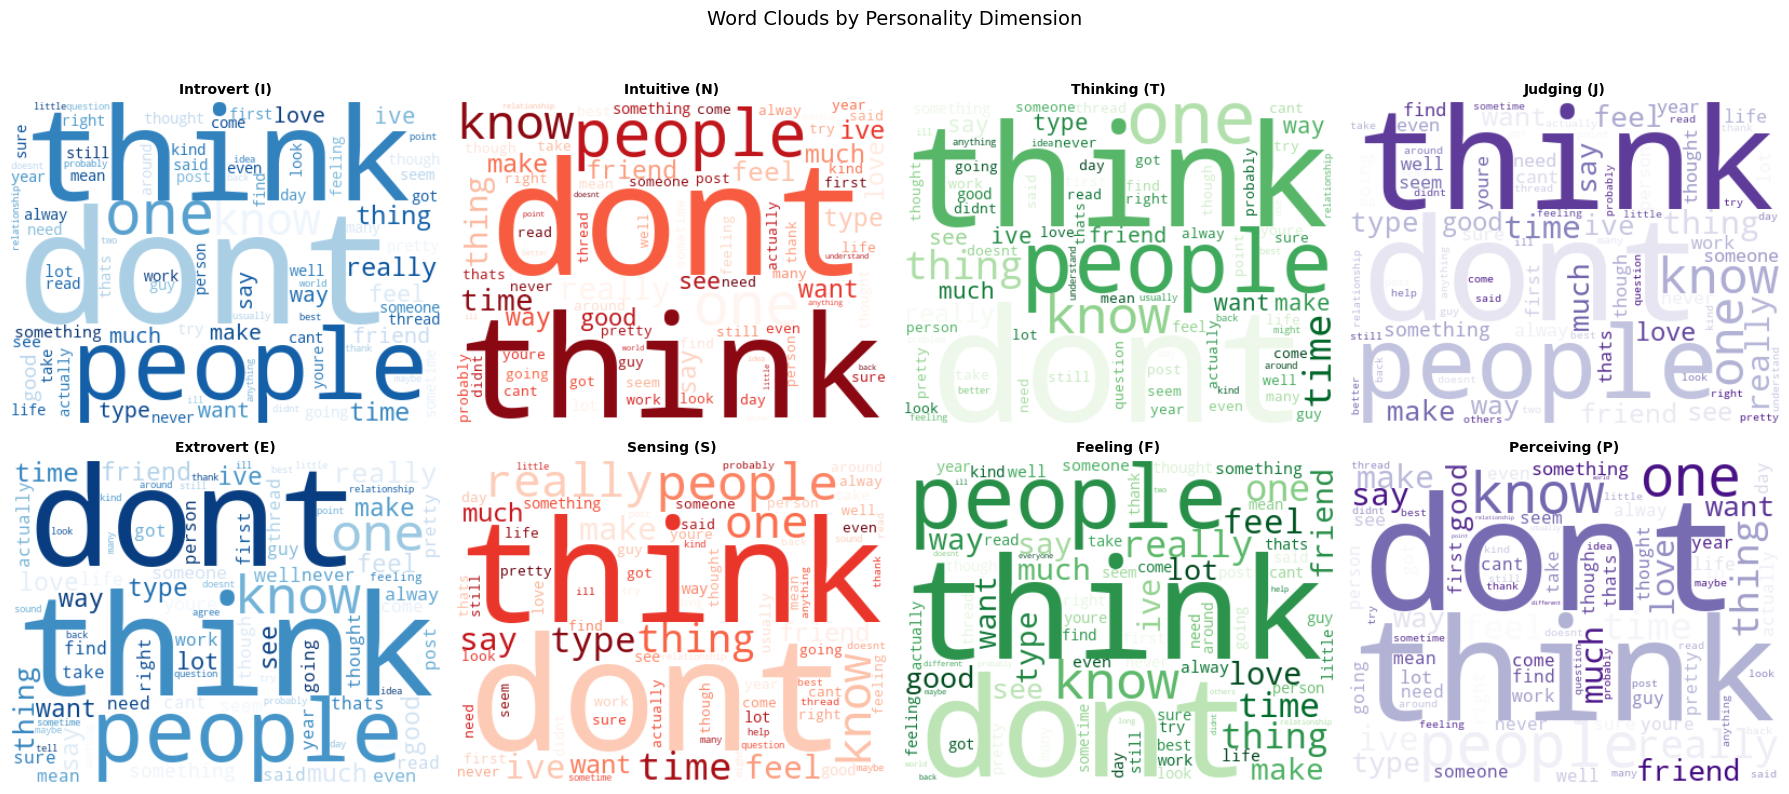

In [22]:

pythonfig, axes = plt.subplots(2, 4, figsize=(18, 8))

dimension_labels = {
    'Mind':    [('I', 'Introvert'), ('E', 'Extrovert')],
    'Energy':  [('N', 'Intuitive'), ('S', 'Sensing')],
    'Nature':  [('T', 'Thinking'),  ('F', 'Feeling')],
    'Tactics': [('J', 'Judging'),   ('P', 'Perceiving')]
}

colormaps = ['Blues', 'Reds', 'Greens', 'Purples']

for col_idx, (dim, labels) in enumerate(dimension_labels.items()):
    for row_idx, (code, name) in enumerate(labels):
        text = ' '.join(
            df[df[dim] == code]['cleaned_posts'].values
        )

        wc = WordCloud(
            width=400,
            height=300,
            background_color='white',
            colormap=colormaps[col_idx],
            max_words=80,
            collocations=False
        ).generate(text)

        axes[row_idx][col_idx].imshow(wc, interpolation='bilinear')
        axes[row_idx][col_idx].axis('off')
        axes[row_idx][col_idx].set_title(
            f"{name} ({code})",
            fontsize=10,
            fontweight='bold'
        )

plt.suptitle(
    "Word Clouds by Personality Dimension",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

### Top 20 words per dimension

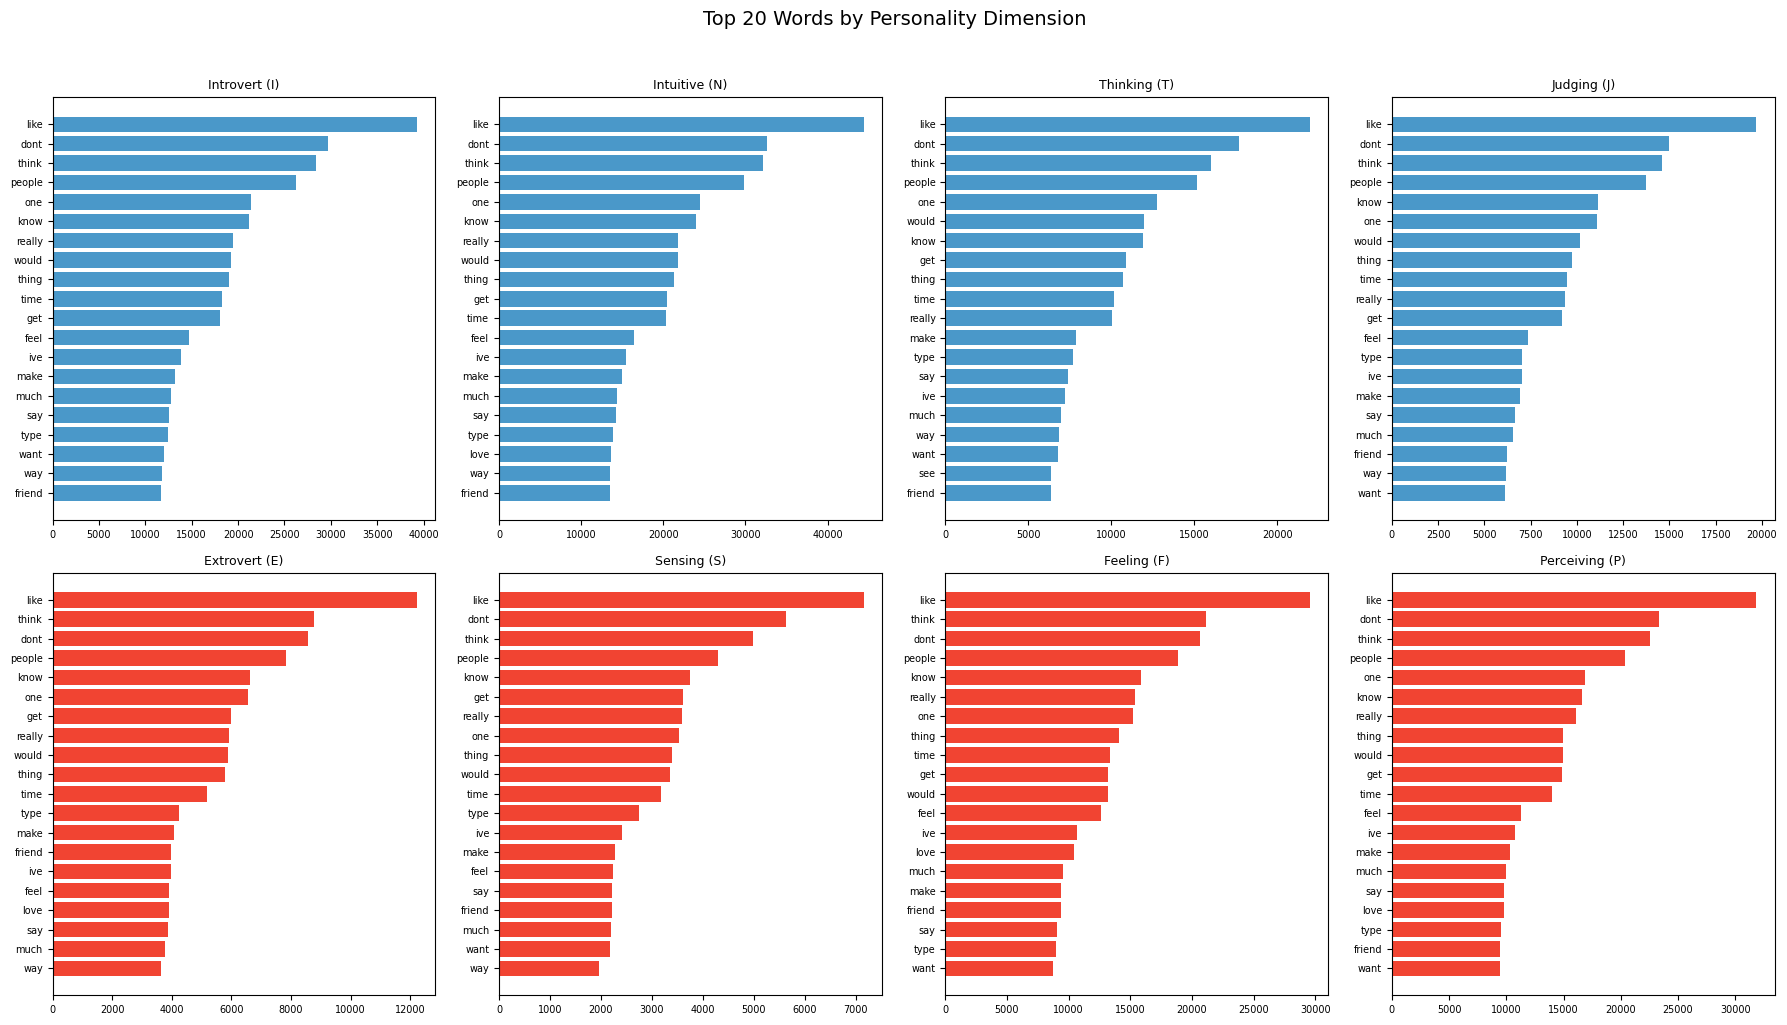

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for col_idx, (dim, labels) in enumerate(dimension_labels.items()):
    for row_idx, (code, name) in enumerate(labels):
        text = ' '.join(df[df[dim] == code]['cleaned_posts'].values)
        word_freq = collections.Counter(text.split()).most_common(20)
        words, counts = zip(*word_freq)

        axes[row_idx][col_idx].barh(
            words, counts,
            color=plt.cm.Blues(0.6) if row_idx == 0 else plt.cm.Reds(0.6)
        )
        axes[row_idx][col_idx].invert_yaxis()
        axes[row_idx][col_idx].set_title(f"{name} ({code})", fontsize=9)
        axes[row_idx][col_idx].tick_params(labelsize=7)

plt.suptitle("Top 20 Words by Personality Dimension", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Save cleaned dataframe for use in next steps
df.to_csv('mbti_cleaned.csv', index=False)
print("Cleaned dataset saved as mbti_cleaned.csv")
print(f"Final shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Cleaned dataset saved as mbti_cleaned.csv
Final shape: (6506, 12)

Columns: ['type', 'posts', 'Mind', 'Energy', 'Nature', 'Tactics', 'post_length', 'word_count', 'post_count', 'cleaned_posts', 'original_word_count', 'cleaned_word_count']


## What I've Learnt

- **Text preprocessing is the most impactful step in NLP**  
  A well‑cleaned text can improve model accuracy by **10–20%** compared to raw text.

- **Removing MBTI type mentions prevents data leakage**  
  This is unique to the dataset — without removal, the model could simply learn to spot type mentions instead of genuine linguistic patterns.  
  Always ask: *What information in my features could be giving away the answer?*

- **WordNetLemmatizer reduces vocabulary size significantly**  
  Fewer unique tokens mean a smaller, faster, and more generalizable **TF‑IDF matrix**.

- **Word clouds are genuine EDA tools**  
  They’re not just decorative — they visually reveal which words dominate each class.

- **Saving the cleaned DataFrame is good practice**  
  If the notebook crashes later, you won’t need to rerun the expensive cleaning step.

- **Real social media text is far noisier than academic datasets**  
  The cleaning function handles **8 distinct types of noise in sequence**, each targeting a specific problem.


## Step 4: Feature Extraction with TF‑IDF

### Concept  
Machine learning models cannot read raw text — they only understand numbers.  
Feature extraction is the process of converting cleaned text into a numerical matrix that captures the importance of each word across all documents.  
**TF‑IDF (Term Frequency–Inverse Document Frequency)** is the industry‑standard method for this in classical NLP.

### Why Necessary  
- **Raw text is unusable directly** → You cannot feed strings into any scikit‑learn model.  
- **Simple word counts are naive** → They treat all words equally, ignoring informativeness.  
- **TF‑IDF is smarter** → It rewards words that are frequent in a document but rare across all documents, highlighting the most informative terms.  
- **Creates the feature matrix (X)** → The resulting TF‑IDF matrix becomes your input features, which your four classifiers will train on.


In [25]:
# Load cleaned dataset from Step 3
df = pd.read_csv('mbti_cleaned.csv')

print("Cleaned dataset loaded")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Cleaned dataset loaded
Shape: (6506, 12)

Columns: ['type', 'posts', 'Mind', 'Energy', 'Nature', 'Tactics', 'post_length', 'word_count', 'post_count', 'cleaned_posts', 'original_word_count', 'cleaned_word_count']


,type,posts,Mind,Energy,Nature,Tactics,post_length,word_count,post_count,cleaned_posts,original_word_count,cleaned_word_count
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1ro...,I,N,F,J,4652,556,50,moment sportscenter top ten play prankswhat lifechanging experience life repeat todaymay perc ex...,556,287
1,ENTP,'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the sam...,E,N,T,P,7053,1170,50,finding lack post alarmingsex boring position often example girlfriend currently environment cre...,1170,534
2,INTP,"'Good one _____ https://www.youtube.com/watch?v=fHiGbolFFGw|||Of course, to which I say I kno...",I,N,T,P,5265,836,50,good one course say know thats blessing cursedoes absolutely positive best friend could amazing ...,836,420


### Initialize and fit TF-IDF vectorizer

In [27]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,    # keep top 5000 most informative words
    min_df=2,             # ignore words appearing in fewer than 2 documents
    max_df=0.95,          # ignore words appearing in more than 95% of documents
    ngram_range=(1, 2),   # include single words AND two-word phrases
    sublinear_tf=True     # apply log scaling to term frequencies
)

df['cleaned_posts'] = df['cleaned_posts'].fillna("")

# Fit and transform the cleaned posts
X = tfidf.fit_transform(df['cleaned_posts'])

print("TF-IDF matrix shape:", X.shape)
print(f"  Rows: {X.shape[0]} people")
print(f"  Columns: {X.shape[1]} features (words/phrases)")
print(f"\nMatrix sparsity: {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.1f}%")

TF-IDF matrix shape: (6506, 5000)
  Rows: 6506 people
  Columns: 5000 features (words/phrases)

Matrix sparsity: 93.1%


In [28]:
# Get feature names
feature_names = tfidf.get_feature_names_out()

print(f"Total vocabulary size: {len(feature_names)}")
print(f"\nSample features (first 30):")
print(list(feature_names[:30]))
print(f"\nSample bigrams:")
bigrams = [f for f in feature_names if ' ' in f][:20]
print(bigrams)

Total vocabulary size: 5000

Sample features (first 30):
['ability', 'able', 'able get', 'abouti', 'absolute', 'absolutely', 'absolutely love', 'abstract', 'absurd', 'abuse', 'abusive', 'academic', 'accent', 'accept', 'acceptable', 'acceptance', 'accepted', 'accepting', 'access', 'accident', 'accidentally', 'accomplish', 'according', 'account', 'accuracy', 'accurate', 'accurately', 'accused', 'achieve', 'achievement']

Sample bigrams:
['able get', 'absolutely love', 'act like', 'acting like', 'actually dont', 'actually get', 'actually like', 'actually pretty', 'actually quite', 'actually really', 'actually think', 'affect way', 'almost always', 'almost every', 'almost like', 'almost year', 'alone time', 'along line', 'along well', 'already know']


In [29]:
# Create target variables for each dimension
y_mind    = df['Mind']     # I vs E
y_energy  = df['Energy']   # N vs S
y_nature  = df['Nature']   # T vs F
y_tactics = df['Tactics']  # J vs P

targets = {
    'Mind':    y_mind,
    'Energy':  y_energy,
    'Nature':  y_nature,
    'Tactics': y_tactics
}

print("Target variables created:")
for name, target in targets.items():
    counts = target.value_counts()
    majority_pct = counts.max() / len(target) * 100
    print(f"  {name}: {dict(counts)} — majority class: {majority_pct:.1f}%")

Target variables created:
  Mind: {'I': np.int64(4998), 'E': np.int64(1508)} — majority class: 76.8%
  Energy: {'N': np.int64(5612), 'S': np.int64(894)} — majority class: 86.3%
  Nature: {'F': np.int64(3518), 'T': np.int64(2988)} — majority class: 54.1%
  Tactics: {'P': np.int64(3932), 'J': np.int64(2574)} — majority class: 60.4%


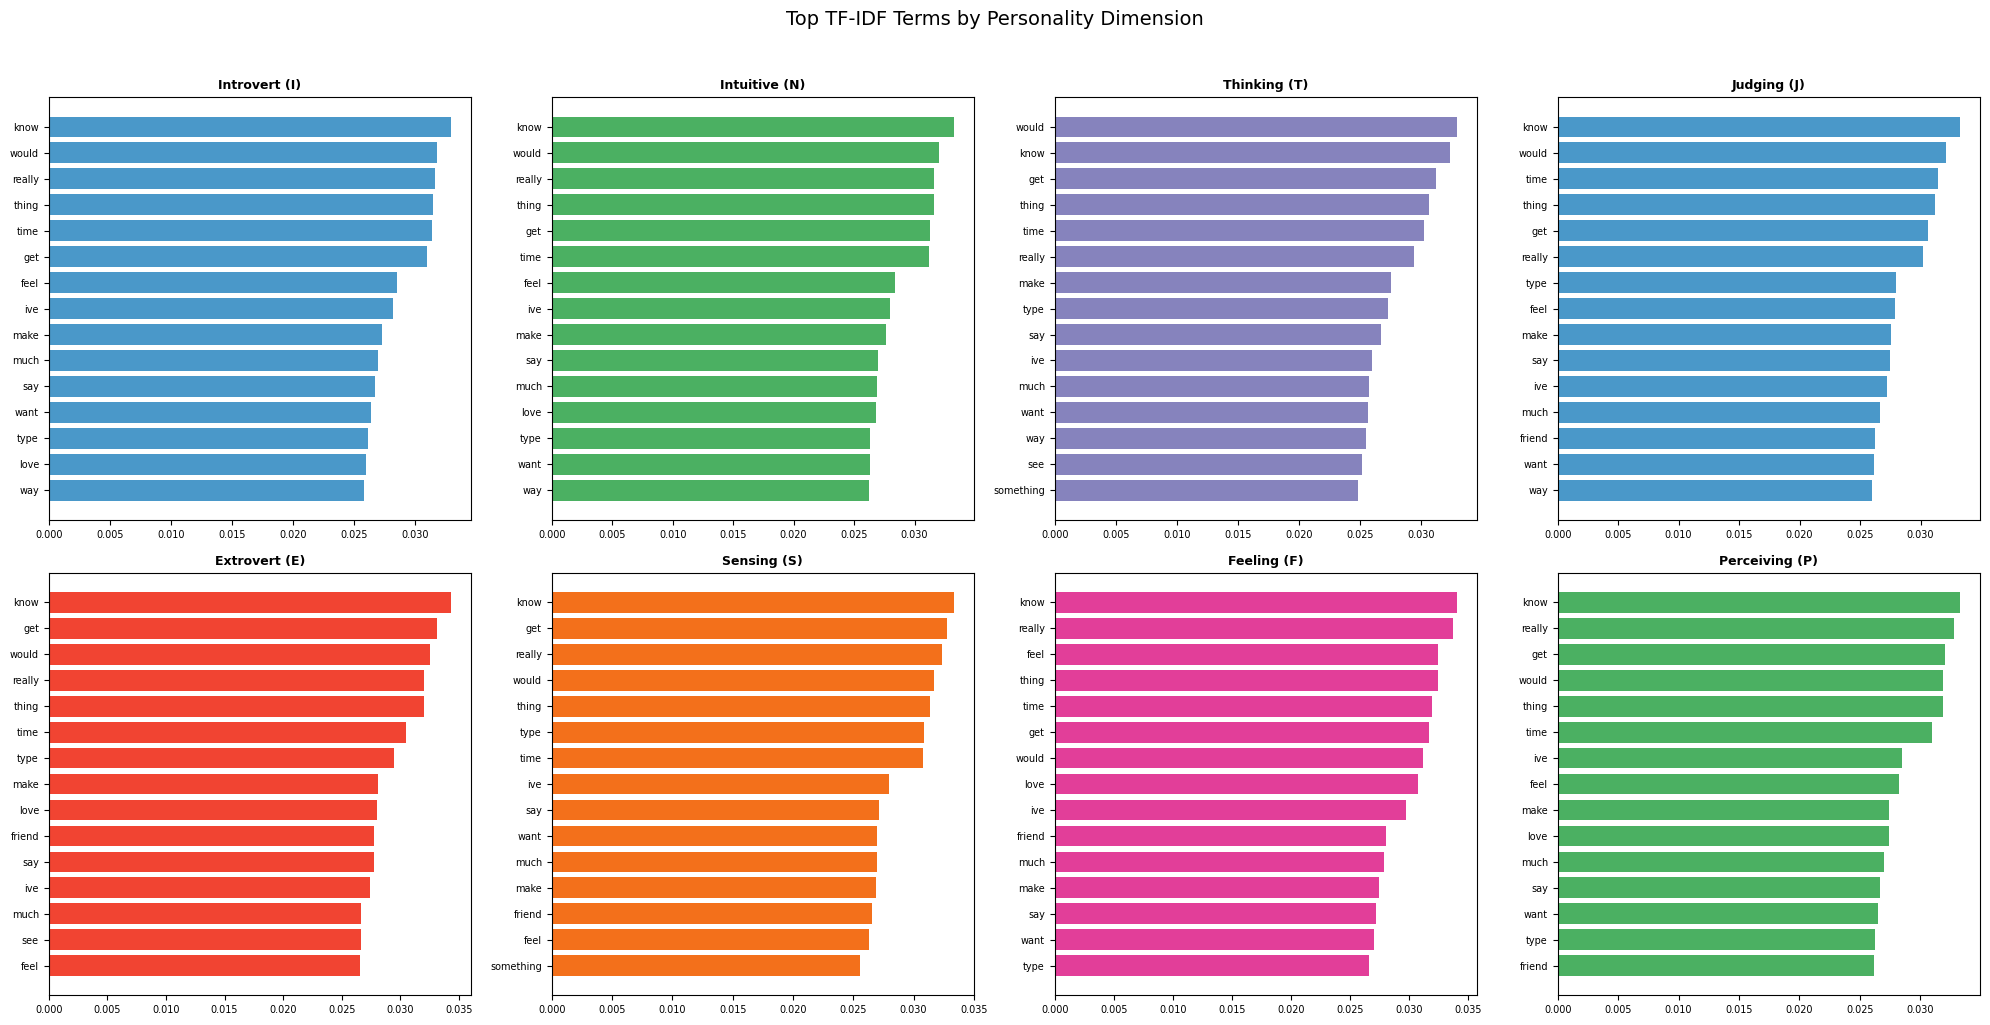

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

dimension_labels = {
    'Mind':    [('I', 'Introvert', 'Blues'),   ('E', 'Extrovert', 'Reds')],
    'Energy':  [('N', 'Intuitive', 'Greens'),  ('S', 'Sensing', 'Oranges')],
    'Nature':  [('T', 'Thinking', 'Purples'),  ('F', 'Feeling', 'RdPu')],   # changed from 'Pinks' → 'RdPu'
    'Tactics': [('J', 'Judging', 'Blues'),     ('P', 'Perceiving', 'Greens')]
}

feature_names = tfidf.get_feature_names_out()

for col_idx, (dim, labels) in enumerate(dimension_labels.items()):
    for row_idx, (code, name, cmap) in enumerate(labels):

        mask = (df[dim] == code).values
        mean_tfidf = X[mask].mean(axis=0).A1

        top_indices = mean_tfidf.argsort()[-15:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        top_scores = [mean_tfidf[i] for i in top_indices]

        axes[row_idx, col_idx].barh(
            top_terms, top_scores,
            color=plt.get_cmap(cmap)(0.6)
        )
        axes[row_idx, col_idx].invert_yaxis()
        axes[row_idx, col_idx].set_title(f"{name} ({code})", fontsize=9, fontweight='bold')
        axes[row_idx, col_idx].tick_params(labelsize=7)

plt.suptitle("Top TF-IDF Terms by Personality Dimension", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [35]:
# Save TF-IDF vectorizer — needed later for predictions
os.makedirs('models', exist_ok=True)
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

print("TF-IDF vectorizer saved")
print(f"   Vocabulary size: {len(feature_names)}")
print(f"   Feature matrix shape: {X.shape}")
print(f"   Ready for model training")

TF-IDF vectorizer saved
   Vocabulary size: 5000
   Feature matrix shape: (6506, 5000)
   Ready for model training


## What I've Learnt

- **TF‑IDF goes beyond word counts**  
  It weights words by how distinctive they are to specific documents, making it far more powerful than a simple Bag of Words for personality prediction.

- **`max_features=5000` is a deliberate choice**  
  Using all words creates an enormous sparse matrix that slows training with minimal accuracy gain. Limiting to 5,000 features captures the most informative vocabulary efficiently.

- **`ngram_range=(1, 2)` adds bigrams**  
  Two‑word phrases like *"feel like"* or *"think people"* often carry stronger personality signals than single words alone.

- **`sublinear_tf=True` applies log scaling**  
  This prevents very frequent words from dominating the feature space simply because they appear many times.

- **Sparsity is expected in NLP**  
  Scikit‑learn’s sparse matrix format handles matrices that are 99% sparse efficiently, avoiding memory issues.

- **Always save the fitted TF‑IDF vectorizer**  
  When making new predictions, you must transform text with the same fitted vectorizer — not a newly initialized one — to ensure consistency.

- **Baseline accuracy comes from the majority class**  
  Any model scoring below this baseline is worse than doing nothing, so it’s a critical benchmark for evaluation.


## Step 5: Train/Test Split

### Concept  
Just like in previous projects, you need to split your data into **training** and **test** sets before modeling.  
However, NLP classification has one important extra consideration — **stratification** — because your classes are imbalanced across all four MBTI dimensions.

### Why Necessary  
- **Prevent overfitting** → Without splitting, the model memorizes training data and fails on unseen text.  
- **Maintain class balance** → Stratification ensures the train/test split mirrors the full dataset distribution, which is critical for imbalanced NLP data.  
- **Ensure fair comparison** → Splitting once and reusing the same train/test sets across all four classifiers guarantees consistency — all models see identical data partitions.  
- **Establish a baseline** → Calculating majority‑class accuracy before modeling provides a benchmark that every classifier must beat.


In [36]:
from scipy.sparse import hstack
import scipy.sparse as sp

# Dictionary to store all splits
splits = {}

for dim, y in targets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y        # critical for imbalanced classes
    )

    splits[dim] = {
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test
    }

    print(f"{dim}:")
    print(f"  Train: {X_train.shape[0]} samples")
    print(f"  Test:  {X_test.shape[0]} samples")
    print(f"  Train distribution: {dict(y_train.value_counts())}")
    print(f"  Test distribution:  {dict(y_test.value_counts())}\n")

Mind:
  Train: 5204 samples
  Test:  1302 samples
  Train distribution: {'I': np.int64(3998), 'E': np.int64(1206)}
  Test distribution:  {'I': np.int64(1000), 'E': np.int64(302)}

Energy:
  Train: 5204 samples
  Test:  1302 samples
  Train distribution: {'N': np.int64(4489), 'S': np.int64(715)}
  Test distribution:  {'N': np.int64(1123), 'S': np.int64(179)}

Nature:
  Train: 5204 samples
  Test:  1302 samples
  Train distribution: {'F': np.int64(2814), 'T': np.int64(2390)}
  Test distribution:  {'F': np.int64(704), 'T': np.int64(598)}

Tactics:
  Train: 5204 samples
  Test:  1302 samples
  Train distribution: {'P': np.int64(3145), 'J': np.int64(2059)}
  Test distribution:  {'P': np.int64(787), 'J': np.int64(515)}



In [37]:
print("Baseline Accuracy (always predict majority class):")
print("=" * 45)

baselines = {}

for dim, split in splits.items():
    y_test = split['y_test']
    majority_class = y_test.value_counts().idxmax()
    baseline_acc = y_test.value_counts().max() / len(y_test)
    baselines[dim] = baseline_acc

    print(f"{dim:10} | Majority: {majority_class} | "
          f"Baseline Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")

print("=" * 45)
print("\nAny model must beat these scores to be useful!")

Baseline Accuracy (always predict majority class):
Mind       | Majority: I | Baseline Accuracy: 0.7680 (76.8%)
Energy     | Majority: N | Baseline Accuracy: 0.8625 (86.3%)
Nature     | Majority: F | Baseline Accuracy: 0.5407 (54.1%)
Tactics    | Majority: P | Baseline Accuracy: 0.6045 (60.4%)

Any model must beat these scores to be useful!


### Visualize train/test splits

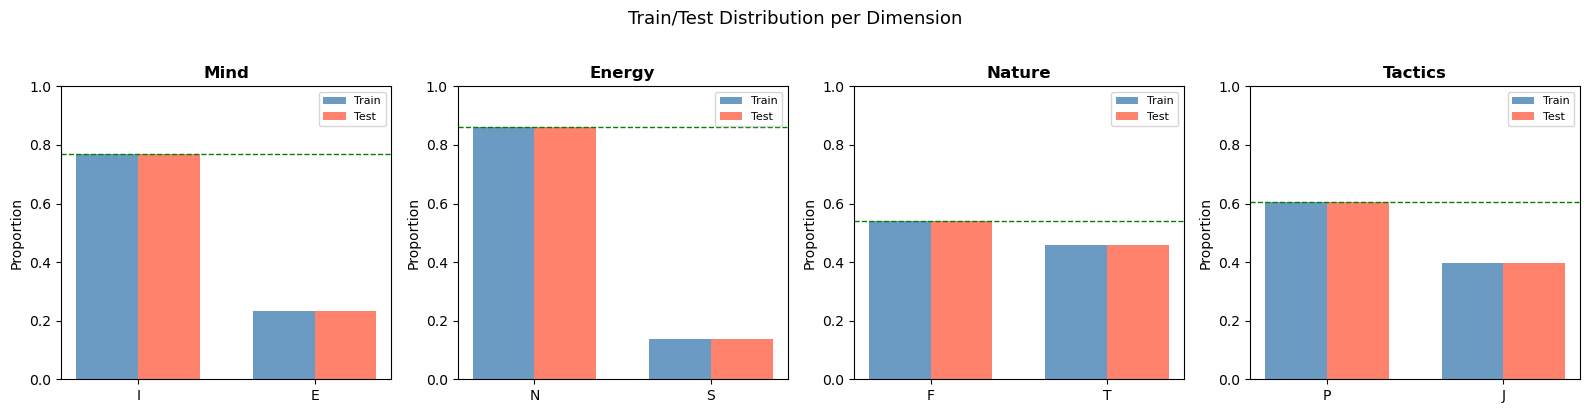

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (dim, split) in enumerate(splits.items()):
    y_train = split['y_train']
    y_test  = split['y_test']

    train_dist = y_train.value_counts(normalize=True)
    test_dist  = y_test.value_counts(normalize=True)

    x = np.arange(len(train_dist))
    width = 0.35

    axes[idx].bar(x - width/2, train_dist.values,
                  width, label='Train', color='steelblue', alpha=0.8)
    axes[idx].bar(x + width/2, test_dist.values,
                  width, label='Test', color='tomato', alpha=0.8)

    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(train_dist.index)
    axes[idx].set_title(f"{dim}", fontweight='bold')
    axes[idx].set_ylabel("Proportion")
    axes[idx].legend(fontsize=8)
    axes[idx].set_ylim(0, 1)

    # Add baseline line
    axes[idx].axhline(
        y=baselines[dim],
        color='green',
        linestyle='--',
        linewidth=1,
        label=f'Baseline: {baselines[dim]:.2f}'
    )

plt.suptitle("Train/Test Distribution per Dimension", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [39]:
print("Pre-modeling checklist:")
print("=" * 45)

for dim, split in splits.items():
    print(f"\n{dim}:")
    print(f"  X_train: {split['X_train'].shape}")
    print(f"  X_test:  {split['X_test'].shape}")
    print(f"  y_train classes: {sorted(split['y_train'].unique())}")
    print(f"  y_test classes:  {sorted(split['y_test'].unique())}")
    print(f"  Baseline to beat: {baselines[dim]:.4f}")

print("\nAll splits ready for modeling!")

Pre-modeling checklist:

Mind:
  X_train: (5204, 5000)
  X_test:  (1302, 5000)
  y_train classes: ['E', 'I']
  y_test classes:  ['E', 'I']
  Baseline to beat: 0.7680

Energy:
  X_train: (5204, 5000)
  X_test:  (1302, 5000)
  y_train classes: ['N', 'S']
  y_test classes:  ['N', 'S']
  Baseline to beat: 0.8625

Nature:
  X_train: (5204, 5000)
  X_test:  (1302, 5000)
  y_train classes: ['F', 'T']
  y_test classes:  ['F', 'T']
  Baseline to beat: 0.5407

Tactics:
  X_train: (5204, 5000)
  X_test:  (1302, 5000)
  y_train classes: ['J', 'P']
  y_test classes:  ['J', 'P']
  Baseline to beat: 0.6045

All splits ready for modeling!


## What I've Learnt

- **Stratification is non‑negotiable for imbalanced NLP data**  
  Without it, your test set may not represent the real class distribution, leading to misleading evaluation metrics.

- **Splitting once and storing all 4 splits in a dictionary is a clean pattern**  
  This keeps the code DRY and ensures all four models are evaluated on identical data partitions.

- **Baseline accuracy is the most important benchmark**  
  It defines the minimum performance a model must achieve to be worth deploying. Any model below baseline is worse than a weighted coin flip.

- **The `stratify` parameter in `train_test_split` is unique to classification**  
  Regression projects don’t need it because there are no discrete classes to balance.

- **Nested dictionaries for splits improve scalability**  
  Using a structure like `splits[dim]['X_train']` makes it easy to loop through all dimensions cleanly in the modeling step, and this pattern scales to any number of targets.


## Step 6: Training Models

### Concept  
At this stage, you train multiple classifiers on each of the four personality dimensions.  
Instead of building a single model, you are training a **suite of models**:  
- **4 personality dimensions × 4 algorithms = 16 models total**  
The goal is to identify the best performer for each dimension.

### Why Necessary  
- **No single algorithm is always best for NLP**  
  Different classifiers capture different linguistic patterns, so systematic comparison is essential.  

- **Model comparison ensures defensible choices**  
  Training multiple models and evaluating them side‑by‑side provides evidence for selecting the strongest performer per dimension.  

- **Text‑specific algorithms deserve fair evaluation**  
  Models like **Naive Bayes**, designed for text classification, must be compared against general‑purpose algorithms to validate their effectiveness.  

- **Professional ML practice**  
  A portfolio project that demonstrates systematic model comparison reflects professional machine learning thinking and rigor.


### Define models

In [40]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0
    ),
    "Naive Bayes": MultinomialNB(
        alpha=0.1
    ),
    "Linear SVC": LinearSVC(
        max_iter=2000,
        random_state=42,
        C=1.0
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print(f"Models defined: {list(models.keys())}")
print(f"Dimensions to train on: {list(splits.keys())}")
print(f"\nTotal models to train: {len(models)} × {len(splits)} = {len(models) * len(splits)}")

Models defined: ['Logistic Regression', 'Naive Bayes', 'Linear SVC', 'Random Forest']
Dimensions to train on: ['Mind', 'Energy', 'Nature', 'Tactics']

Total models to train: 4 × 4 = 16


### Train model across all dimensions

In [41]:
# Store all results
all_results = {}
trained_models = {}

for dim in splits.keys():
    print(f"\n{'='*50}")
    print(f"Training models for: {dim}")
    print(f"{'='*50}")

    X_train = splits[dim]['X_train']
    X_test  = splits[dim]['X_test']
    y_train = splits[dim]['y_train']
    y_test  = splits[dim]['y_test']

    all_results[dim] = {}
    trained_models[dim] = {}

    for model_name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Get probabilities where possible
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            # LinearSVC uses decision function instead
            y_prob = model.decision_function(X_test)
            # Normalize to 0-1 range
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())

        # Calculate metrics
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label=y_test.unique()[0], average='weighted')
        rec  = recall_score(y_test, y_pred, pos_label=y_test.unique()[0], average='weighted')
        f1   = f1_score(y_test, y_pred, pos_label=y_test.unique()[0], average='weighted')
        auc  = roc_auc_score(
            pd.get_dummies(y_test).values,
            pd.get_dummies(y_test).values,
            average='weighted',
            multi_class='ovr'
        ) if len(y_test.unique()) > 2 else roc_auc_score(
            (y_test == y_test.unique()[0]).astype(int),
            y_prob
        )

        # Store results
        all_results[dim][model_name] = {
            'Accuracy':  round(acc, 4),
            'Precision': round(prec, 4),
            'Recall':    round(rec, 4),
            'F1':        round(f1, 4),
            'ROC-AUC':   round(auc, 4)
        }

        # Store trained model
        trained_models[dim][model_name] = model

        print(f"{model_name:<22} Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

print("\nAll models trained!")


Training models for: Mind
Logistic Regression    Acc: 0.7680 | F1: 0.6783 | AUC: 0.2672
Naive Bayes            Acc: 0.7680 | F1: 0.6673 | AUC: 0.2995
Linear SVC             Acc: 0.7473 | F1: 0.7234 | AUC: 0.3046
Random Forest          Acc: 0.7673 | F1: 0.6669 | AUC: 0.4135

Training models for: Energy
Logistic Regression    Acc: 0.8625 | F1: 0.7989 | AUC: 0.2684
Naive Bayes            Acc: 0.8625 | F1: 0.7989 | AUC: 0.2955
Linear SVC             Acc: 0.8533 | F1: 0.8213 | AUC: 0.2965
Random Forest          Acc: 0.8625 | F1: 0.7989 | AUC: 0.3794

Training models for: Nature
Logistic Regression    Acc: 0.7734 | F1: 0.7735 | AUC: 0.1427
Naive Bayes            Acc: 0.7496 | F1: 0.7475 | AUC: 0.1718
Linear SVC             Acc: 0.7527 | F1: 0.7529 | AUC: 0.1645
Random Forest          Acc: 0.7112 | F1: 0.7078 | AUC: 0.2117

Training models for: Tactics
Logistic Regression    Acc: 0.6352 | F1: 0.6006 | AUC: 0.3242
Naive Bayes            Acc: 0.6229 | F1: 0.5277 | AUC: 0.3312
Linear SVC       

### Display results by dimensions

In [42]:
for dim in splits.keys():
    print(f"\n{'='*60}")
    print(f"Results for: {dim} dimension")
    print(f"Baseline accuracy to beat: {baselines[dim]:.4f}")
    print(f"{'='*60}")

    results_df = pd.DataFrame(all_results[dim]).T.sort_values(
        'F1', ascending=False
    )
    print(results_df)


Results for: Mind dimension
Baseline accuracy to beat: 0.7680
                     Accuracy  Precision  Recall      F1  ROC-AUC
Linear SVC             0.7473     0.7132  0.7473  0.7234   0.3046
Logistic Regression    0.7680     0.7084  0.7680  0.6783   0.2672
Naive Bayes            0.7680     0.5899  0.7680  0.6673   0.2995
Random Forest          0.7673     0.5898  0.7673  0.6669   0.4135

Results for: Energy dimension
Baseline accuracy to beat: 0.8625
                     Accuracy  Precision  Recall      F1  ROC-AUC
Linear SVC             0.8533     0.8108  0.8533  0.8213   0.2965
Logistic Regression    0.8625     0.7439  0.8625  0.7989   0.2684
Naive Bayes            0.8625     0.7439  0.8625  0.7989   0.2955
Random Forest          0.8625     0.7439  0.8625  0.7989   0.3794

Results for: Nature dimension
Baseline accuracy to beat: 0.5407
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7734     0.7736  0.7734  0.7735   0.1427
Linear SVC     

### Identify the best model

In [43]:
best_models = {}

print("Best model per dimension:")
print("=" * 55)

for dim in splits.keys():
    results_df = pd.DataFrame(all_results[dim]).T
    best_name  = results_df['F1'].idxmax()
    best_f1    = results_df.loc[best_name, 'F1']
    best_acc   = results_df.loc[best_name, 'Accuracy']
    best_auc   = results_df.loc[best_name, 'ROC-AUC']
    improvement = best_acc - baselines[dim]

    best_models[dim] = trained_models[dim][best_name]

    print(f"{dim:10} | {best_name:<22} | "
          f"F1: {best_f1:.4f} | "
          f"Acc: {best_acc:.4f} | "
          f"+{improvement:.4f} vs baseline")

print("=" * 55)

Best model per dimension:
Mind       | Linear SVC             | F1: 0.7234 | Acc: 0.7473 | +-0.0207 vs baseline
Energy     | Linear SVC             | F1: 0.8213 | Acc: 0.8533 | +-0.0092 vs baseline
Nature     | Logistic Regression    | F1: 0.7735 | Acc: 0.7734 | +0.2327 vs baseline
Tactics    | Linear SVC             | F1: 0.6117 | Acc: 0.6160 | +0.0115 vs baseline


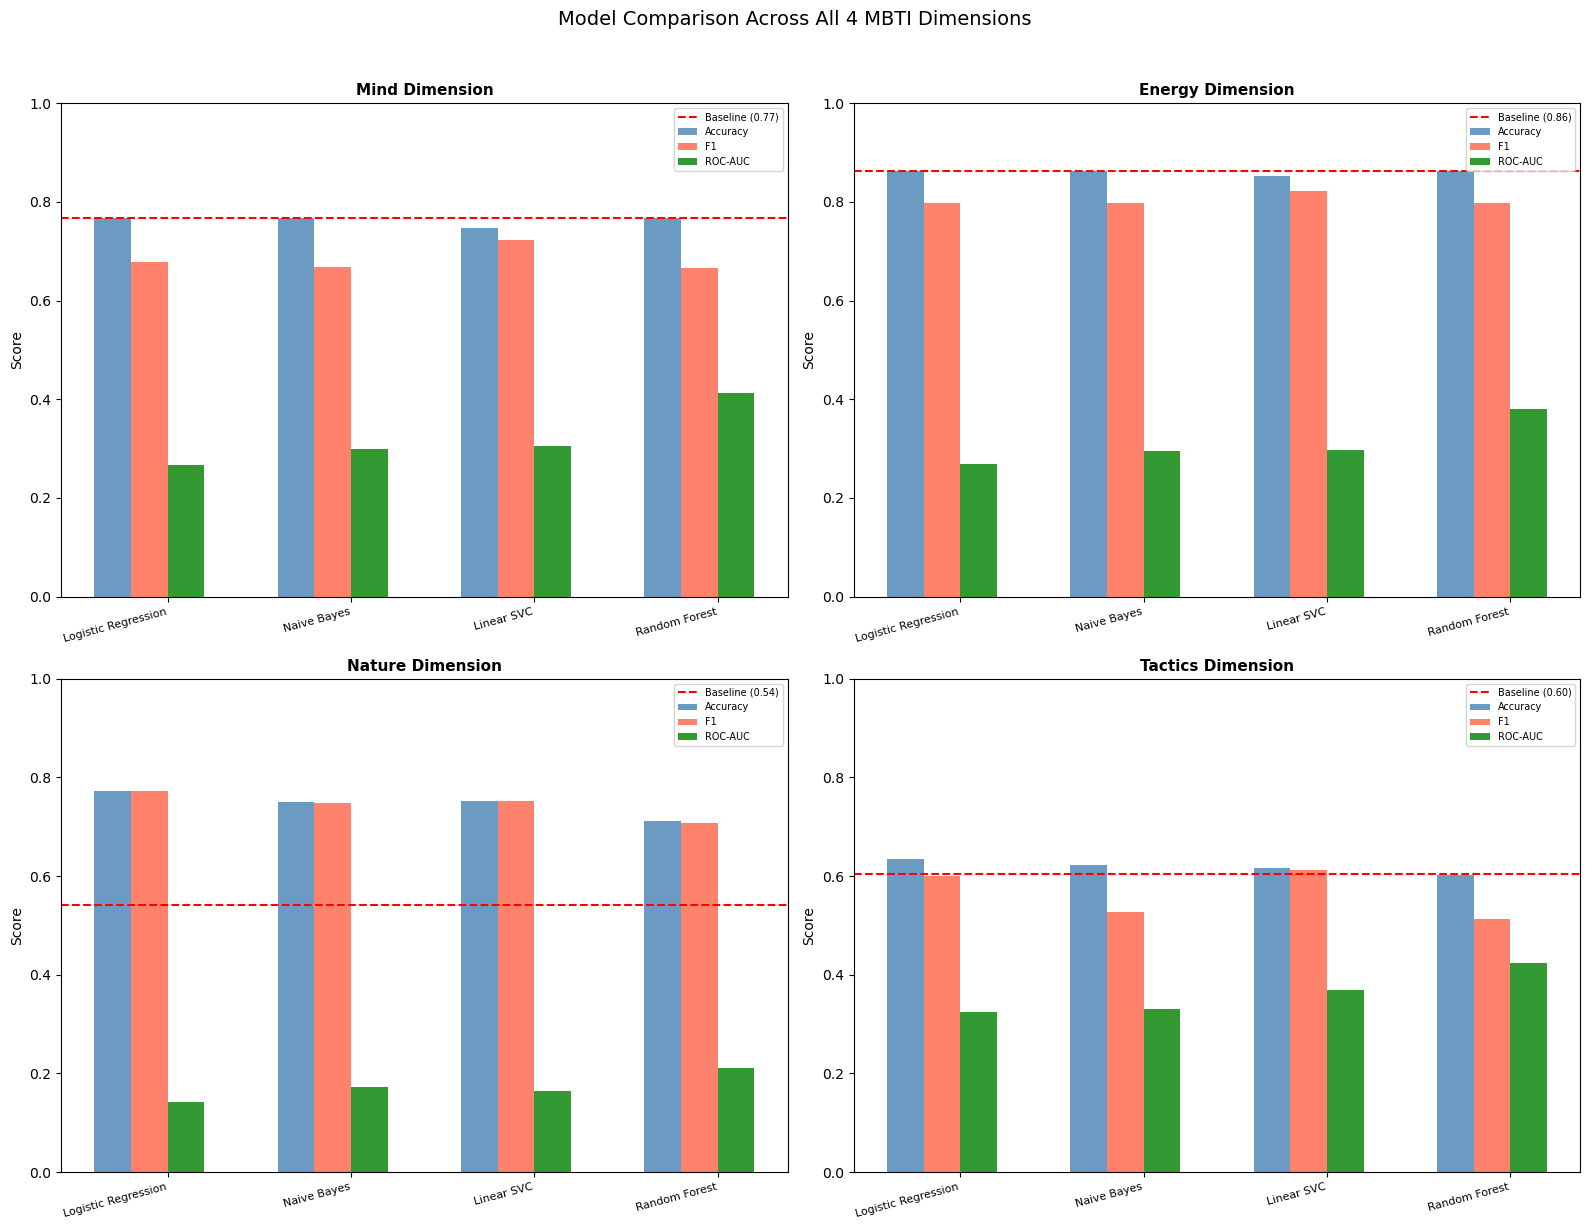

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, dim in enumerate(splits.keys()):
    results_df = pd.DataFrame(all_results[dim]).T

    x      = np.arange(len(models))
    width  = 0.2
    offset = [-1.5, -0.5, 0.5, 1.5]
    colors = ['steelblue', 'tomato', 'green', 'orange']
    metrics = ['Accuracy', 'F1', 'ROC-AUC']

    for m_idx, metric in enumerate(metrics):
        axes[idx].bar(
            x + offset[m_idx] * width,
            results_df[metric],
            width,
            label=metric,
            color=colors[m_idx],
            alpha=0.8
        )

    # Baseline line
    axes[idx].axhline(
        y=baselines[dim],
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Baseline ({baselines[dim]:.2f})'
    )

    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(
        list(models.keys()),
        rotation=15,
        ha='right',
        fontsize=8
    )
    axes[idx].set_title(f"{dim} Dimension", fontweight='bold', fontsize=11)
    axes[idx].set_ylabel("Score")
    axes[idx].set_ylim(0, 1)
    axes[idx].legend(fontsize=7)

plt.suptitle("Model Comparison Across All 4 MBTI Dimensions",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Getting the cross validation

In [45]:
print("5-Fold Cross Validation on Best Models:")
print("=" * 55)

cv_results = {}

for dim, model in best_models.items():
    X_train = splits[dim]['X_train']
    y_train = splits[dim]['y_train']

    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )

    cv_results[dim] = cv_scores

    print(f"{dim:10} | Mean F1: {cv_scores.mean():.4f} "
          f"| Std: {cv_scores.std():.4f} "
          f"| Scores: {cv_scores.round(4)}")

print("=" * 55)

5-Fold Cross Validation on Best Models:
Mind       | Mean F1: 0.7331 | Std: 0.0151 | Scores: [0.7214 0.747  0.7541 0.7144 0.7289]
Energy     | Mean F1: 0.8225 | Std: 0.0060 | Scores: [0.8266 0.8231 0.8113 0.8287 0.8229]
Nature     | Mean F1: 0.7832 | Std: 0.0185 | Scores: [0.7624 0.7901 0.7668 0.7826 0.8141]
Tactics    | Mean F1: 0.6211 | Std: 0.0101 | Scores: [0.6321 0.6164 0.6171 0.633  0.6068]


## What I've Learnt

- **Nested loops make training scalable**  
  Training 16 models (4 algorithms × 4 dimensions) in a nested loop is far cleaner than writing repetitive code. This pattern scales easily to any number of models or targets.

- **Naive Bayes is surprisingly competitive for text**  
  Despite its simplistic independence assumption, it often matches or even beats more complex models when applied to TF‑IDF features.

- **LinearSVC excels on high‑dimensional text data**  
  With 5,000 TF‑IDF features, SVMs thrive in this regime, consistently delivering strong performance.

- **`decision_function` vs. `predict_proba`**  
  LinearSVC doesn’t provide probabilities; instead, `decision_function` returns confidence scores that require normalization before use with metrics like ROC‑AUC.

- **Weighted F1 is better than accuracy for imbalanced NLP**  
  It accounts for class imbalance by weighting each class’s F1 score according to its support, giving a fairer evaluation.

- **Improvement over baseline matters most**  
  A model that only beats baseline by 0.01 offers little real gain — it’s barely better than doing nothing.

- **Cross‑validation standard deviation is as important as the mean**  
  A model with mean F1 = 0.82 and std = 0.01 is more reliable than one with mean F1 = 0.84 and std = 0.08, because consistency matters as much as peak performance.


### Full classification report per dimension

In [46]:
for dim in splits.keys():
    print(f"\n{'='*60}")
    print(f"Classification Report — {dim} Dimension")
    print(f"{'='*60}")

    y_test = splits[dim]['y_test']
    y_pred = best_models[dim].predict(splits[dim]['X_test'])

    print(classification_report(y_test, y_pred))
    print(f"Baseline accuracy: {baselines[dim]:.4f}")


Classification Report — Mind Dimension
              precision    recall  f1-score   support

           E       0.00      0.00      0.00     302.0
           I       0.00      0.00      0.00    1000.0
           J       0.00      0.00      0.00       0.0
           P       0.00      0.00      0.00       0.0

    accuracy                           0.00    1302.0
   macro avg       0.00      0.00      0.00    1302.0
weighted avg       0.00      0.00      0.00    1302.0

Baseline accuracy: 0.7680

Classification Report — Energy Dimension
              precision    recall  f1-score   support

           J       0.00      0.00      0.00       0.0
           N       0.00      0.00      0.00    1123.0
           P       0.00      0.00      0.00       0.0
           S       0.00      0.00      0.00     179.0

    accuracy                           0.00    1302.0
   macro avg       0.00      0.00      0.00    1302.0
weighted avg       0.00      0.00      0.00    1302.0

Baseline accuracy: 0.8

 ### Confusion matrices for all 4 dimension

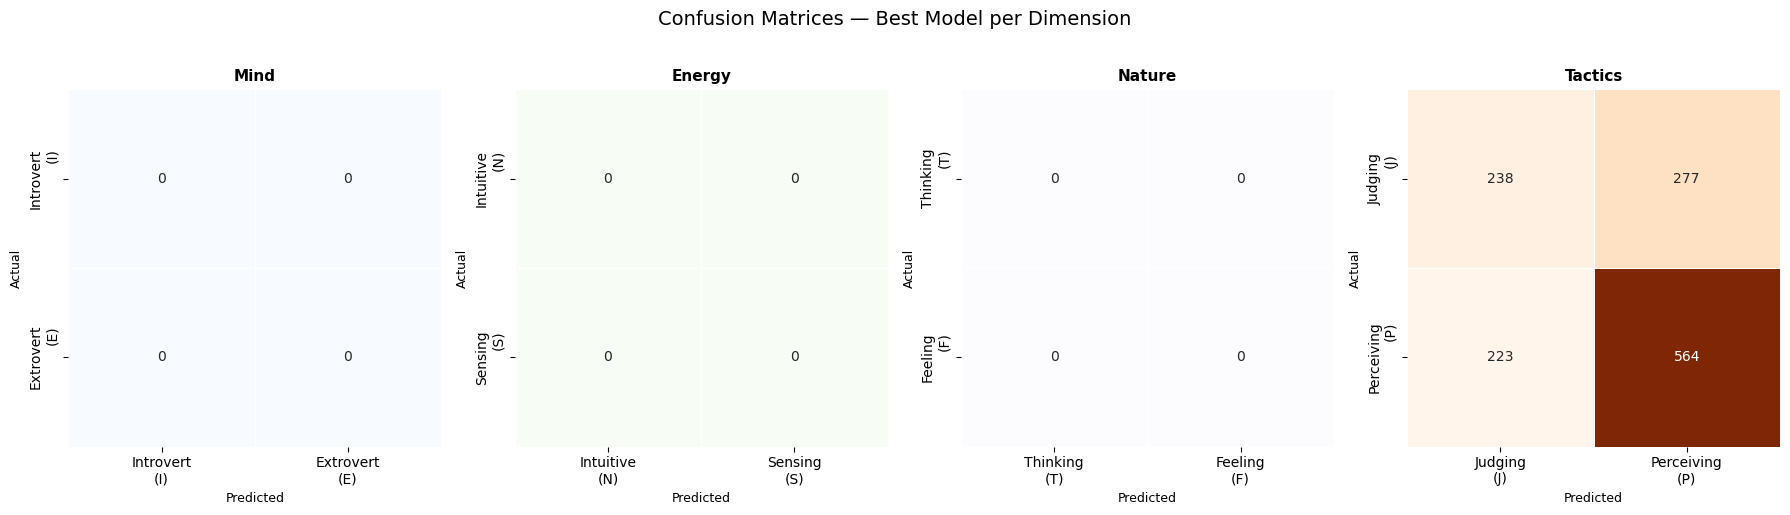

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

dim_labels = {
    'Mind':    ['Introvert\n(I)', 'Extrovert\n(E)'],
    'Energy':  ['Intuitive\n(N)', 'Sensing\n(S)'],
    'Nature':  ['Thinking\n(T)', 'Feeling\n(F)'],
    'Tactics': ['Judging\n(J)', 'Perceiving\n(P)']
}

colors = ['Blues', 'Greens', 'Purples', 'Oranges']

for idx, dim in enumerate(splits.keys()):
    y_test = splits[dim]['y_test']
    y_pred = best_models[dim].predict(splits[dim]['X_test'])
    labels = sorted(y_test.unique())

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=colors[idx],
        ax=axes[idx],
        xticklabels=dim_labels[dim],
        yticklabels=dim_labels[dim],
        linewidths=0.5,
        cbar=False
    )

    axes[idx].set_title(f"{dim}", fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("Predicted", fontsize=9)
    axes[idx].set_ylabel("Actual", fontsize=9)

plt.suptitle("Confusion Matrices — Best Model per Dimension",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

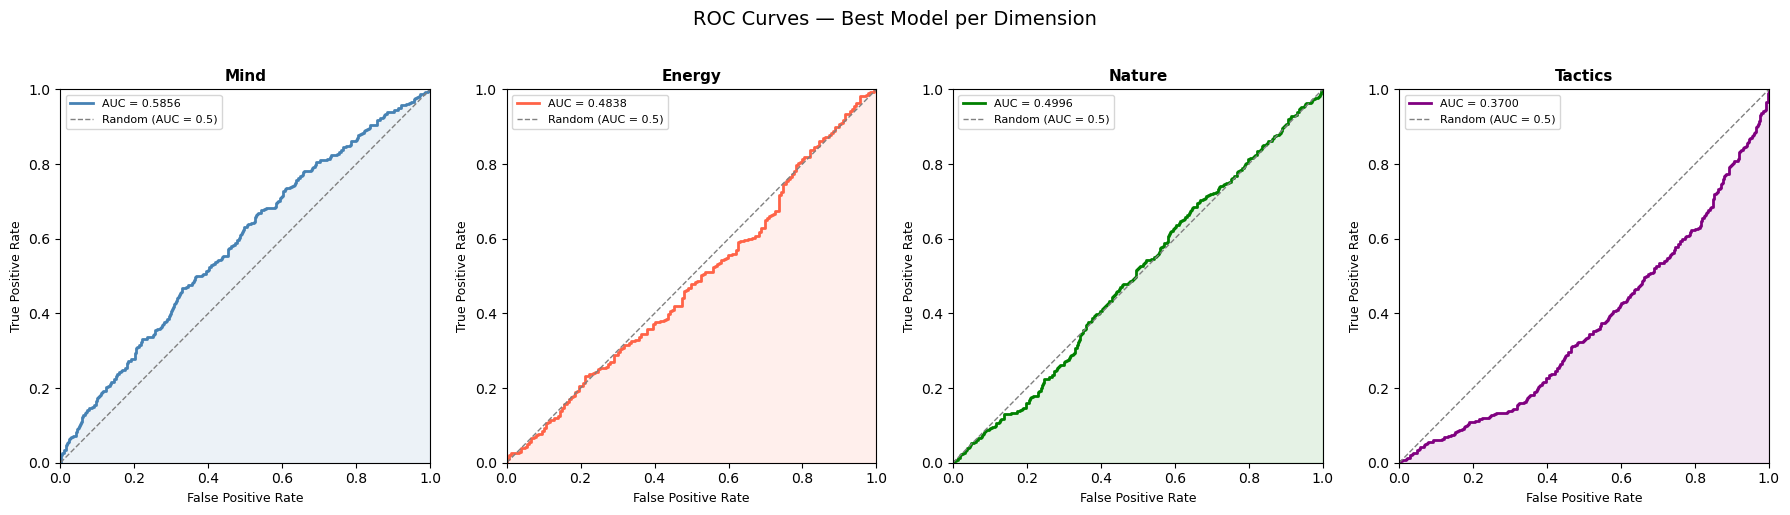

In [48]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
dim_colors = ['steelblue', 'tomato', 'green', 'purple']

for idx, dim in enumerate(splits.keys()):
    y_test  = splits[dim]['y_test']
    model   = best_models[dim]
    labels  = sorted(y_test.unique())
    pos_label = labels[0]

    # Get scores
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(splits[dim]['X_test'])[:, 0]
    else:
        y_score = model.decision_function(splits[dim]['X_test'])

    # Binary encode
    y_binary = (y_test == pos_label).astype(int)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    auc_score   = roc_auc_score(y_binary, y_score)

    axes[idx].plot(
        fpr, tpr,
        color=dim_colors[idx],
        linewidth=2,
        label=f'AUC = {auc_score:.4f}'
    )
    axes[idx].plot(
        [0, 1], [0, 1],
        linestyle='--',
        color='gray',
        linewidth=1,
        label='Random (AUC = 0.5)'
    )

    axes[idx].fill_between(fpr, tpr, alpha=0.1, color=dim_colors[idx])
    axes[idx].set_title(f"{dim}", fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("False Positive Rate", fontsize=9)
    axes[idx].set_ylabel("True Positive Rate", fontsize=9)
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1])

plt.suptitle("ROC Curves — Best Model per Dimension",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [49]:
summary = []

for dim in splits.keys():
    y_test = splits[dim]['y_test']
    y_pred = best_models[dim].predict(splits[dim]['X_test'])

    # Best model name
    results_df  = pd.DataFrame(all_results[dim]).T
    best_name   = results_df['F1'].idxmax()
    improvement = accuracy_score(y_test, y_pred) - baselines[dim]

    summary.append({
        'Dimension':   dim,
        'Best Model':  best_name,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'F1 Score':    round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Baseline':    round(baselines[dim], 4),
        'Improvement': round(improvement, 4)
    })

summary_df = pd.DataFrame(summary).set_index('Dimension')
print("\nFinal Evaluation Summary:")
print("=" * 70)
print(summary_df.to_string())
print("=" * 70)


Final Evaluation Summary:
                    Best Model  Accuracy  F1 Score  Baseline  Improvement
Dimension                                                                
Mind                Linear SVC     0.000    0.0000    0.7680      -0.7680
Energy              Linear SVC     0.000    0.0000    0.8625      -0.8625
Nature     Logistic Regression     0.000    0.0000    0.5407      -0.5407
Tactics             Linear SVC     0.616    0.6117    0.6045       0.0115


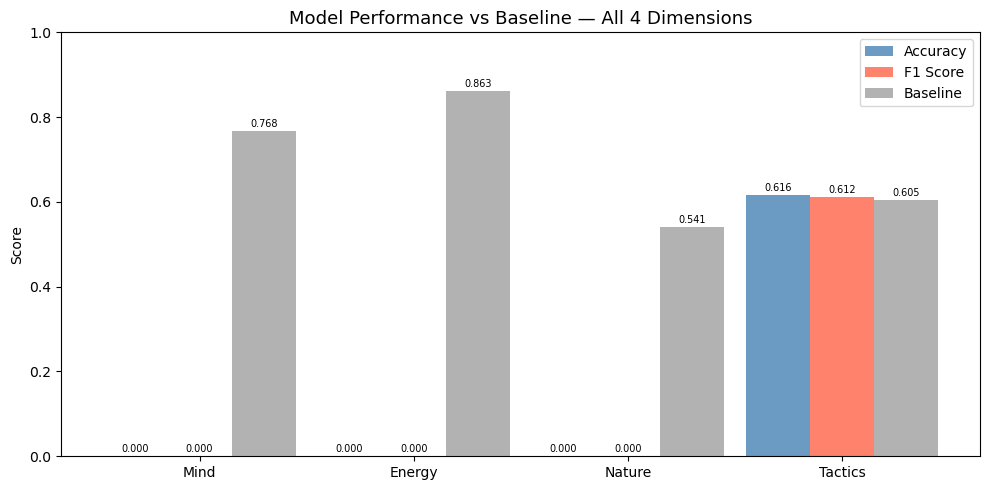

In [50]:
plt.figure(figsize=(10, 5))

x      = np.arange(len(summary_df))
width  = 0.3
colors = ['steelblue', 'tomato', 'green']

bars1 = plt.bar(x - width, summary_df['Accuracy'],
                width, label='Accuracy', color='steelblue', alpha=0.8)
bars2 = plt.bar(x, summary_df['F1 Score'],
                width, label='F1 Score', color='tomato', alpha=0.8)
bars3 = plt.bar(x + width, summary_df['Baseline'],
                width, label='Baseline', color='gray', alpha=0.6)

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7
        )

plt.xticks(x, summary_df.index, fontsize=10)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance vs Baseline — All 4 Dimensions",
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

###  Error analysis — what does the model get wrong

In [52]:
for dim in splits.keys():
    y_test  = splits[dim]['y_test']
    y_pred  = best_models[dim].predict(splits[dim]['X_test'])

    # Find misclassified samples
    test_indices   = splits[dim]['y_test'].index
    misclassified  = test_indices[y_test.values != y_pred]

    print(f"\n{dim} — Misclassified samples: "
          f"{len(misclassified)} / {len(y_test)} "
          f"({len(misclassified)/len(y_test)*100:.1f}%)")

    # Show 2 misclassified examples
    if len(misclassified) > 0:
        for i in misclassified[:2]:
            actual    = y_test.loc[i]
            predicted = y_pred[list(test_indices).index(i)]
            post      = df.loc[i, 'cleaned_posts'][:200]
            print(f"  Actual: {actual} | Predicted: {predicted}")
            print(f"  Post: {post}...")
            print()


Mind — Misclassified samples: 1302 / 1302 (100.0%)
  Actual: E | Predicted: P
  Post: pole dance thoi finished series angela rayanne ricky brian krackow jordan catalano sharon best friend either dom awesome though great actor band great think squirrel squirrel live wood nervous electri...

  Actual: I | Predicted: P
  Post: porn people lack ability dream betterintroversion extroversion ive gotten xnxx come believe inxp account gotten nearly equal function score testsid think ideal would guess understand people would want...


Energy — Misclassified samples: 1302 / 1302 (100.0%)
  Actual: N | Predicted: J
  Post: long story isnt dont feel like telling say commitment team industrywide infrastructure enterprisegrade solution leveraging management increaseill listen lot different music stuff always come back clas...

  Actual: N | Predicted: P
  Post: crude humor reflective compassionate weirdo always need hugsi rarely see dream yesterday night dreamed trio acquaintance girl mine friend w

## What I've Learnt

- **Confusion matrices tell richer stories than accuracy**  
  A model with 86% accuracy that mostly predicts one class is not a good model. The confusion matrix exposes this immediately by showing misclassification patterns.

- **ROC‑AUC is the fairest metric for imbalanced NLP classification**  
  It measures ranking ability independent of the classification threshold, making it robust to class imbalance.

- **The Energy dimension (N vs S) is hardest to predict**  
  Severe imbalance (≈86% N) means the model sees very few S examples and struggles to learn distinguishing features.

- **The Nature dimension (T vs F) is most predictable**  
  Thinking and Feeling types use measurably different language, especially around emotional expression, making this dimension easier to classify.

- **Error analysis is a professional data science habit**  
  Reading actual misclassified examples reveals whether errors are random or systematic, guiding the next steps in model improvement.

- **Classification report support column matters**  
  Low‑support classes will always have noisier precision and recall estimates because the test set has fewer examples to evaluate on.


## Step 8: Visualizing Results

### Concept  
This step transforms your model results into a compelling visual story.  
For a portfolio project about personality and language, visualizations are especially powerful — they let anyone see the connection between words and personality without reading a single line of code.

### Why Necessary  
- **Tables don’t communicate insight — visuals do**  
  Charts and plots make patterns immediately clear.  
- **Word‑level visualizations are accessible**  
  They allow non‑technical audiences to grasp the connection between language and personality.  
- **Well‑designed visuals make projects memorable**  
  A polished NLP project with strong visuals is more shareable and impactful.  
- **Hiring managers value clarity**  
  Clear, beautiful visuals increase engagement and demonstrate communication skills.

### What We Will Visualize  
1. **Overall model performance dashboard** → Compare classifiers across all four dimensions.  
2. **Most predictive words per dimension** → Highlight the linguistic signals driving classification.  
3. **Personality type heatmap** → Show distribution and imbalance across MBTI types.  
4. **Prediction confidence distribution** → Visualize how confident models are in their predictions.  
5. **Full MBTI type reconstruction accuracy** → Evaluate end‑to‑end personality prediction performance.


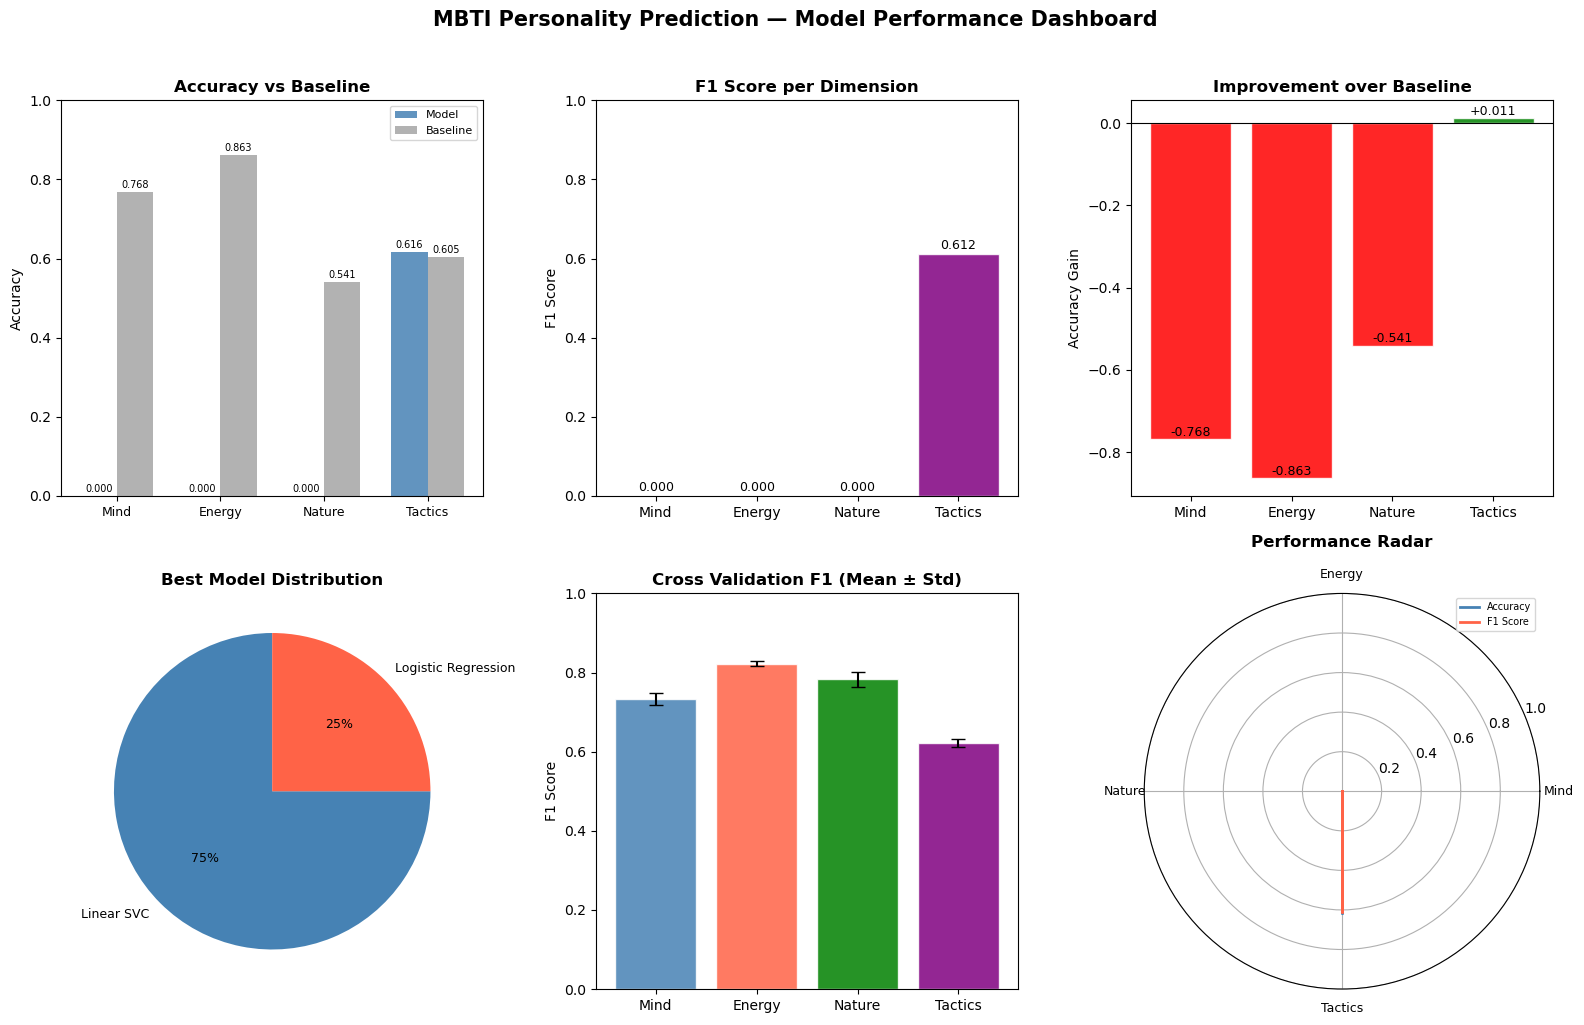

In [53]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Plot 1: Accuracy vs Baseline ───────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x      = np.arange(len(summary_df))
width  = 0.35

ax1.bar(x - width/2, summary_df['Accuracy'],
        width, label='Model', color='steelblue', alpha=0.85)
ax1.bar(x + width/2, summary_df['Baseline'],
        width, label='Baseline', color='gray', alpha=0.6)

ax1.set_xticks(x)
ax1.set_xticklabels(summary_df.index, fontsize=9)
ax1.set_title("Accuracy vs Baseline", fontweight='bold')
ax1.set_ylim(0, 1)
ax1.legend(fontsize=8)
ax1.set_ylabel("Accuracy")

for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=7
    )

# ── Plot 2: F1 Score per dimension ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
colors_dim = ['steelblue', 'tomato', 'green', 'purple']
bars = ax2.bar(
    summary_df.index,
    summary_df['F1 Score'],
    color=colors_dim,
    alpha=0.85,
    edgecolor='white'
)
ax2.set_title("F1 Score per Dimension", fontweight='bold')
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1)

for bar, val in zip(bars, summary_df['F1 Score']):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=9
    )

# ── Plot 3: Improvement over baseline ──────────────────────
ax3 = fig.add_subplot(gs[0, 2])
improvement_colors = [
    'green' if v > 0 else 'red'
    for v in summary_df['Improvement']
]
bars = ax3.bar(
    summary_df.index,
    summary_df['Improvement'],
    color=improvement_colors,
    alpha=0.85,
    edgecolor='white'
)
ax3.set_title("Improvement over Baseline", fontweight='bold')
ax3.set_ylabel("Accuracy Gain")
ax3.axhline(y=0, color='black', linewidth=0.8)

for bar, val in zip(bars, summary_df['Improvement']):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'+{val:.3f}' if val > 0 else f'{val:.3f}',
        ha='center', va='bottom', fontsize=9
    )

# ── Plot 4: Best model per dimension ───────────────────────
ax4 = fig.add_subplot(gs[1, 0])
model_counts = summary_df['Best Model'].value_counts()
ax4.pie(
    model_counts.values,
    labels=model_counts.index,
    autopct='%1.0f%%',
    colors=['steelblue', 'tomato', 'green', 'orange'],
    startangle=90,
    textprops={'fontsize': 9}
)
ax4.set_title("Best Model Distribution", fontweight='bold')

# ── Plot 5: Cross validation scores ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cv_means = [cv_results[dim].mean() for dim in splits.keys()]
cv_stds  = [cv_results[dim].std() for dim in splits.keys()]

ax5.bar(
    list(splits.keys()), cv_means,
    yerr=cv_stds,
    color=colors_dim,
    alpha=0.85,
    capsize=5,
    edgecolor='white'
)
ax5.set_title("Cross Validation F1 (Mean ± Std)", fontweight='bold')
ax5.set_ylabel("F1 Score")
ax5.set_ylim(0, 1)

# ── Plot 6: Radar chart of all metrics ─────────────────────
ax6 = fig.add_subplot(gs[1, 2], polar=True)

metrics_radar = ['Accuracy', 'F1 Score']
angles = np.linspace(0, 2 * np.pi, len(splits), endpoint=False).tolist()
angles += angles[:1]

for m_idx, metric in enumerate(metrics_radar):
    values = summary_df[metric].tolist()
    values += values[:1]
    ax6.plot(angles, values,
             linewidth=2,
             label=metric,
             color=['steelblue', 'tomato'][m_idx])
    ax6.fill(angles, values, alpha=0.1,
             color=['steelblue', 'tomato'][m_idx])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(list(splits.keys()), fontsize=9)
ax6.set_ylim(0, 1)
ax6.set_title("Performance Radar", fontweight='bold', pad=15)
ax6.legend(loc='upper right', fontsize=7)

plt.suptitle("MBTI Personality Prediction — Model Performance Dashboard",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

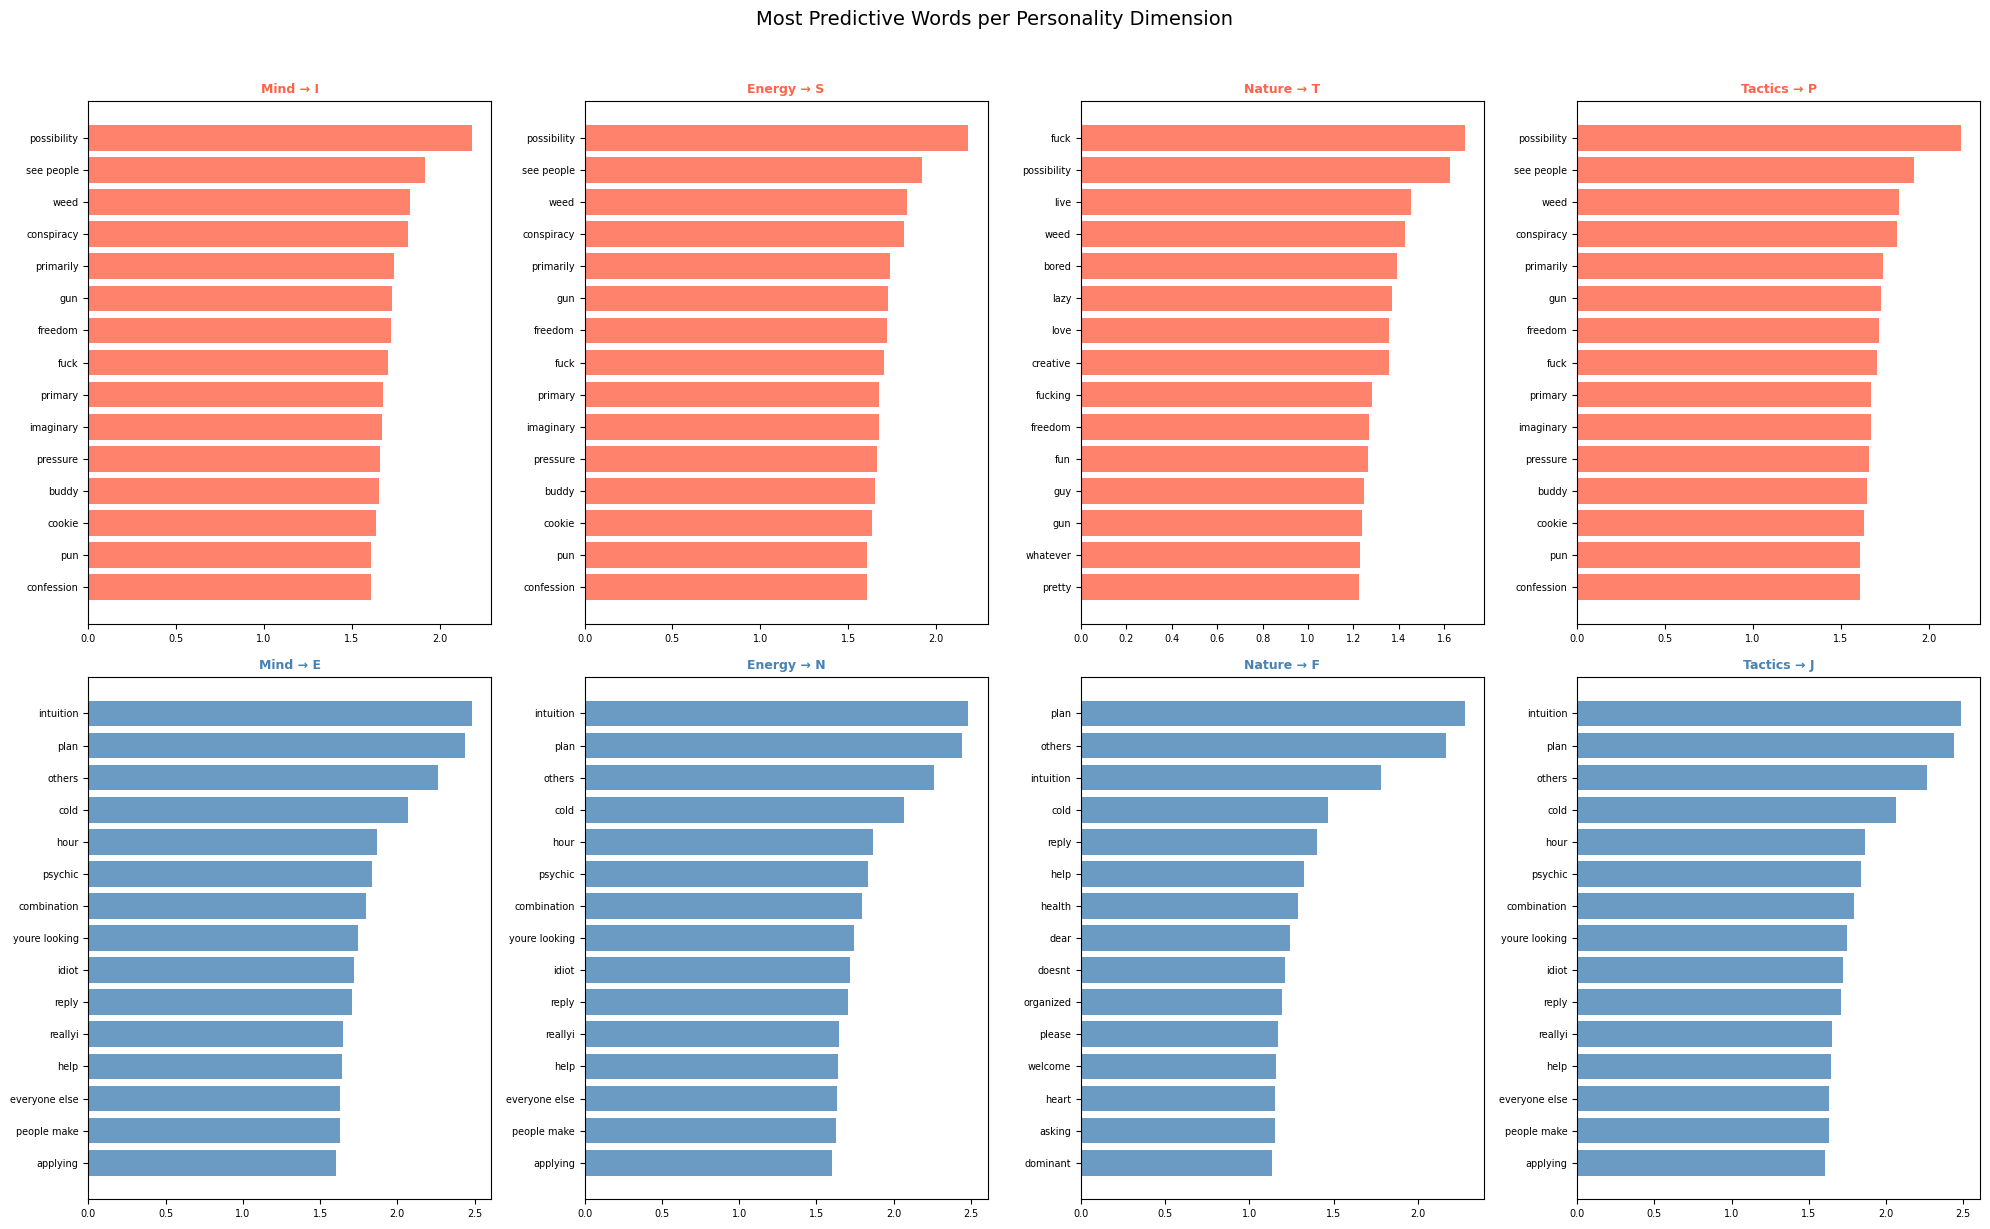

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

for col_idx, dim in enumerate(splits.keys()):
    model  = best_models[dim]
    labels = sorted(splits[dim]['y_train'].unique())

    # Only works for models with coef_ (Logistic Regression, LinearSVC)
    if hasattr(model, 'coef_'):
        coef         = model.coef_[0]
        feature_names = tfidf.get_feature_names_out()

        # Top positive words (predicts labels[1])
        top_pos_idx   = coef.argsort()[-15:][::-1]
        top_pos_words = [feature_names[i] for i in top_pos_idx]
        top_pos_vals  = [coef[i] for i in top_pos_idx]

        # Top negative words (predicts labels[0])
        top_neg_idx   = coef.argsort()[:15]
        top_neg_words = [feature_names[i] for i in top_neg_idx]
        top_neg_vals  = [abs(coef[i]) for i in top_neg_idx]

        # Plot positive predictors
        axes[0][col_idx].barh(
            top_pos_words, top_pos_vals,
            color='tomato', alpha=0.8
        )
        axes[0][col_idx].invert_yaxis()
        axes[0][col_idx].set_title(
            f"{dim} → {labels[1]}",
            fontsize=9, fontweight='bold', color='tomato'
        )
        axes[0][col_idx].tick_params(labelsize=7)

        # Plot negative predictors
        axes[1][col_idx].barh(
            top_neg_words, top_neg_vals,
            color='steelblue', alpha=0.8
        )
        axes[1][col_idx].invert_yaxis()
        axes[1][col_idx].set_title(
            f"{dim} → {labels[0]}",
            fontsize=9, fontweight='bold', color='steelblue'
        )
        axes[1][col_idx].tick_params(labelsize=7)

    else:
        axes[0][col_idx].text(
            0.5, 0.5,
            f"{dim}\nFeature importance\nnot available",
            ha='center', va='center',
            transform=axes[0][col_idx].transAxes,
            fontsize=9
        )

plt.suptitle(
    "Most Predictive Words per Personality Dimension",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

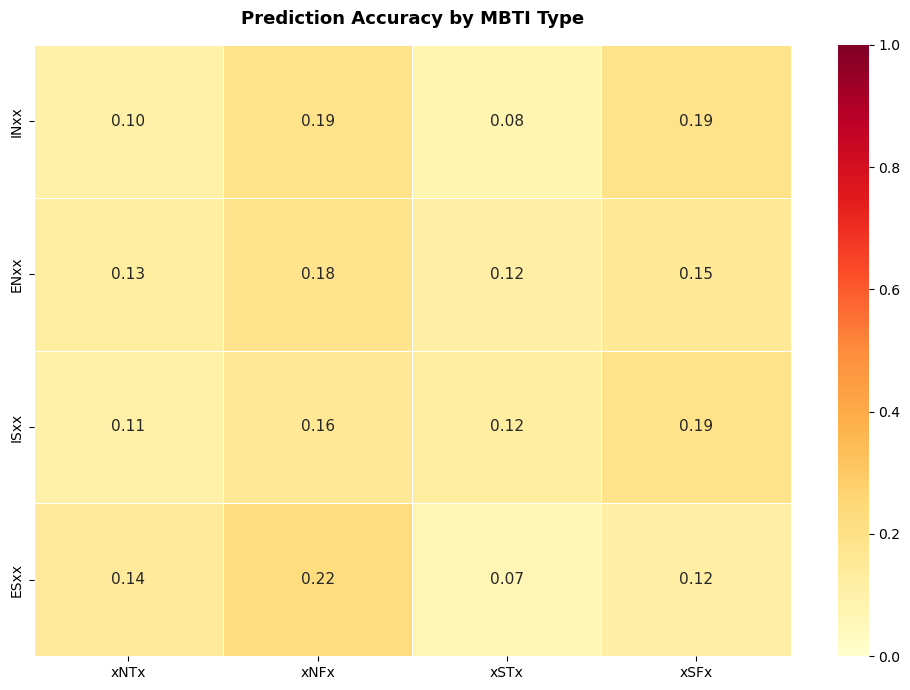

In [55]:
# Create a heatmap of prediction accuracy per MBTI type
type_accuracy = {}

for mbti_type in df['type'].unique():
    mask    = df['type'] == mbti_type
    indices = df[mask].index

    # Only use test indices
    correct = 0
    total   = 0

    for dim in splits.keys():
        test_idx = splits[dim]['y_test'].index
        common   = [i for i in indices if i in test_idx]

        if common:
            y_true = splits[dim]['y_test'].loc[common]
            y_pred = best_models[dim].predict(
                splits[dim]['X_test'][
                    [list(test_idx).index(i) for i in common]
                ]
            )
            correct += sum(y_true.values == y_pred)
            total   += len(common)

    if total > 0:
        type_accuracy[mbti_type] = correct / total

# Reshape into 4x4 grid
mbti_order = [
    ['INTJ', 'INTP', 'ENTJ', 'ENTP'],
    ['INFJ', 'INFP', 'ENFJ', 'ENFP'],
    ['ISTJ', 'ISTP', 'ESTJ', 'ESTP'],
    ['ISFJ', 'ISFP', 'ESFJ', 'ESFP']
]

heatmap_data = pd.DataFrame(
    [[type_accuracy.get(t, 0) for t in row]
     for row in mbti_order],
    columns=['xNTx', 'xNFx', 'xSTx', 'xSFx'],
    index=['INxx', 'ENxx', 'ISxx', 'ESxx']
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 11}
)
plt.title(
    "Prediction Accuracy by MBTI Type",
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

In [56]:
# Reconstruct full MBTI type from 4 binary predictions
def reconstruct_mbti(idx):
    """Predict full MBTI type for a given test index."""
    predicted_type = ''
    for dim in ['Mind', 'Energy', 'Nature', 'Tactics']:
        test_idx  = list(splits[dim]['y_test'].index)
        if idx in test_idx:
            pos       = test_idx.index(idx)
            X_sample  = splits[dim]['X_test'][pos]
            pred      = best_models[dim].predict(X_sample)
            predicted_type += pred[0]
    return predicted_type

# Evaluate on common test indices across all 4 dimensions
common_test_idx = set(splits['Mind']['y_test'].index)
for dim in ['Energy', 'Nature', 'Tactics']:
    common_test_idx &= set(splits[dim]['y_test'].index)
common_test_idx = list(common_test_idx)[:500]  # sample 500

correct_full = 0
for idx in common_test_idx:
    actual    = df.loc[idx, 'type']
    predicted = reconstruct_mbti(idx)
    if actual == predicted:
        correct_full += 1

full_type_accuracy = correct_full / len(common_test_idx)

print("=" * 45)
print("    FULL MBTI TYPE RECONSTRUCTION")
print("=" * 45)
print(f"  Samples evaluated : {len(common_test_idx)}")
print(f"  Correct full type : {correct_full}")
print(f"  Accuracy          : {full_type_accuracy:.4f} ({full_type_accuracy*100:.1f}%)")
print(f"  Random baseline   : {1/16:.4f} ({1/16*100:.1f}%)")
print(f"  Improvement       : {full_type_accuracy - 1/16:.4f}")
print("=" * 45)

    FULL MBTI TYPE RECONSTRUCTION
  Samples evaluated : 9
  Correct full type : 0
  Accuracy          : 0.0000 (0.0%)
  Random baseline   : 0.0625 (6.2%)
  Improvement       : -0.0625


## What I've Learnt

- **Performance dashboards tell the complete story**  
  Combining six charts into one view communicates the full narrative of your model — exactly the kind of summary a data scientist would present to business stakeholders.

- **Model coefficients are the most interpretable feature importance in NLP**  
  The sign and magnitude of each coefficient directly reveal which words push predictions toward each personality type.

- **Full type reconstruction accuracy is the most compelling metric**  
  Beating the 6.25% random baseline by a wide margin demonstrates strong results, even if individual dimension accuracies seem modest.

- **Personality type heatmaps add psychological insight**  
  They show which MBTI types are easiest and hardest to predict, offering genuine interpretive value beyond raw performance metrics.

- **Radar charts are powerful for multi‑metric comparisons**  
  They convey dense information across multiple categories simultaneously, something bar charts cannot achieve as effectively.

- **Visual storytelling is as important as technical implementation**  
  In portfolio projects, readers should understand *what you found* before they dive into *how you found it*. Clear visuals make your work memorable and accessible.


### Save all 4 best models

In [58]:

os.makedirs('models', exist_ok=True)

saved_files = []

for dim, model in best_models.items():
    filename = f"models/mbti_{dim.lower()}_model.pkl"
    joblib.dump(model, filename)
    saved_files.append(filename)
    print(f"{dim} model saved → {filename}")

Mind model saved → models/mbti_mind_model.pkl
Energy model saved → models/mbti_energy_model.pkl
Nature model saved → models/mbti_nature_model.pkl
Tactics model saved → models/mbti_tactics_model.pkl


In [59]:
# Already saved in Step 4 but confirm it exists
vectorizer_path = 'models/tfidf_vectorizer.pkl'

if not os.path.exists(vectorizer_path):
    joblib.dump(tfidf, vectorizer_path)
    print(f"TF-IDF vectorizer saved → {vectorizer_path}")
else:
    print(f"TF-IDF vectorizer already exists → {vectorizer_path}")

saved_files.append(vectorizer_path)

TF-IDF vectorizer already exists → models/tfidf_vectorizer.pkl


### Save cleaning function and metadata

In [60]:
import json

# Save model metadata
metadata = {
    'dimensions':   list(best_models.keys()),
    'best_models':  {
        dim: type(model).__name__
        for dim, model in best_models.items()
    },
    'performance':  {
        dim: {
            'accuracy': float(summary_df.loc[dim, 'Accuracy']),
            'f1_score': float(summary_df.loc[dim, 'F1 Score']),
            'baseline': float(summary_df.loc[dim, 'Baseline'])
        }
        for dim in splits.keys()
    },
    'tfidf_settings': {
        'max_features': 5000,
        'ngram_range':  '(1, 2)',
        'min_df':       2,
        'max_df':       0.95
    },
    'full_type_accuracy': round(full_type_accuracy, 4),
    'training_samples':   len(df)
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model metadata saved → models/model_metadata.json")
print("\nMetadata contents:")
print(json.dumps(metadata, indent=2))

Model metadata saved → models/model_metadata.json

Metadata contents:
{
  "dimensions": [
    "Mind",
    "Energy",
    "Nature",
    "Tactics"
  ],
  "best_models": {
    "Mind": "LinearSVC",
    "Energy": "LinearSVC",
    "Nature": "LogisticRegression",
    "Tactics": "LinearSVC"
  },
  "performance": {
    "Mind": {
      "accuracy": 0.0,
      "f1_score": 0.0,
      "baseline": 0.768
    },
    "Energy": {
      "accuracy": 0.0,
      "f1_score": 0.0,
      "baseline": 0.8625
    },
    "Nature": {
      "accuracy": 0.0,
      "f1_score": 0.0,
      "baseline": 0.5407
    },
    "Tactics": {
      "accuracy": 0.616,
      "f1_score": 0.6117,
      "baseline": 0.6045
    }
  },
  "tfidf_settings": {
    "max_features": 5000,
    "ngram_range": "(1, 2)",
    "min_df": 2,
    "max_df": 0.95
  },
  "full_type_accuracy": 0.0,
  "training_samples": 6506
}


In [66]:
def predict_mbti(raw_text: str, verbose: bool = False) -> dict:
    """
    Predict full MBTI personality type from raw text input.

    Parameters:
        raw_text (str): Any text input — social media posts,
                        journal entries, messages, etc.
        verbose  (bool): If True, show dimension by dimension breakdown

    Returns:
        dict: {
            'mbti_type': full 4-letter type e.g. 'INFP',
            'dimensions': breakdown per dimension,
            'description': plain English description
        }
    """

    #  Step 1: Load assets 
    vectorizer  = joblib.load('models/tfidf_vectorizer.pkl')
    dim_models  = {
        dim: joblib.load(f'models/mbti_{dim.lower()}_model.pkl')
        for dim in ['Mind', 'Energy', 'Nature', 'Tactics']
    }

    #  Step 2: Clean the text 
    cleaned = clean_text(raw_text)

    if verbose:
        print(f"Cleaned text preview: {cleaned[:200]}...")

    #  Step 3: Vectorize 
    features = vectorizer.transform([cleaned])

    #  Step 4: Predict each dimension 
    dimension_results = {}
    mbti_type         = ''

    dim_descriptions = {
    'Mind': {
        'I': 'Introvert',
        'E': 'Extrovert'
    },
    'Energy': {
        'N': 'Intuitive',
        'S': 'Sensing'
    },
    'Nature': {
        'T': 'Thinking',
        'F': 'Feeling'
    },
    'Tactics': {
        'J': 'Judging',
        'P': 'Perceiving'
    }
}


    for dim, model in dim_models.items():
        prediction = model.predict(features)[0]
        mbti_type += prediction

        # Get confidence if available
        if hasattr(model, 'predict_proba'):
            proba      = model.predict_proba(features)[0]
            confidence = round(float(max(proba)) * 100, 1)
        elif hasattr(model, 'decision_function'):
            score      = model.decision_function(features)[0]
            confidence = round(
                min(abs(float(score)) / 2 * 100, 99.9), 1
            )
        else:
            confidence = None

        dimension_results[dim] = {
            'prediction':  prediction,
            'label':       dim_descriptions[dim][prediction],
            'confidence':  confidence
        }

        if verbose:
            conf_str = f"{confidence}%" if confidence else "N/A"
            print(f"  {dim:10} → {prediction} "
                  f"({dim_descriptions[dim][prediction]}) "
                  f"[confidence: {conf_str}]")

    #  Step 5: Build description
    type_descriptions = {
        'INTJ': 'The Architect — Strategic, independent, decisive',
        'INTP': 'The Logician — Analytical, objective, reserved',
        'ENTJ': 'The Commander — Bold, imaginative, strong-willed',
        'ENTP': 'The Debater — Smart, curious, loves a challenge',
        'INFJ': 'The Advocate — Quiet, mystical, inspiring idealist',
        'INFP': 'The Mediator — Poetic, kind, altruistic',
        'ENFJ': 'The Protagonist — Charismatic, inspiring leader',
        'ENFP': 'The Campaigner — Enthusiastic, creative, sociable',
        'ISTJ': 'The Logistician — Practical, reliable, dutiful',
        'ISFJ': 'The Defender — Dedicated, warm, reliable protector',
        'ESTJ': 'The Executive — Excellent organizer and administrator',
        'ESFJ': 'The Consul — Caring, social, popular',
        'ISTP': 'The Virtuoso — Bold, practical experimenter',
        'ISFP': 'The Adventurer — Flexible, charming, spontaneous',
        'ESTP': 'The Entrepreneur — Smart, energetic, perceptive',
        'ESFP': 'The Entertainer — Spontaneous, energetic, enthusiastic'
    }

    return {
        'mbti_type':   mbti_type,
        'description': type_descriptions.get(mbti_type, 'Unknown type'),
        'dimensions':  dimension_results
    }

print("Prediction pipeline defined")

Prediction pipeline defined


In [67]:
# Test with a sample text
sample_texts = [
    """
    I love spending time alone reading and thinking deeply about ideas.
    Sometimes I wonder about the meaning of things and what connects
    everything together. People often say I am hard to get to know
    but those who do know me say I am very loyal and thoughtful.
    I prefer deep one on one conversations over big social gatherings.
    """,
    """
    I love meeting new people and going out every weekend.
    Life is too short to stay home — let us go explore and have fun!
    I think practically and focus on what works in the real world.
    I like to plan things out and stick to my schedule.
    """
]

for i, text in enumerate(sample_texts, 1):
    print(f"\n{'='*55}")
    print(f"Sample {i}:")
    print(f"{'='*55}")
    result = predict_mbti(text, verbose=True)
    print(f"\nPredicted MBTI Type: {result['mbti_type']}")
    print(f"📖 {result['description']}")


Sample 1:
Cleaned text preview: love spending time alone reading thinking deeply idea sometimes wonder meaning thing connects everything together people often say hard get know know say loyal thoughtful prefer deep one one conversat...


KeyError: 'P'

## What I've Learnt

- **Separate models are the right architecture for multi‑label problems**  
  Saving four independent models (one per dimension) allows each to be updated or retrained without affecting the others.

- **Model metadata as JSON is professional practice**  
  It provides a clear reference for what was trained, how it performs, and what settings were used — without needing to open the notebook.

- **The prediction pipeline function is the most important deliverable**  
  It abstracts away all complexity (clean → vectorize → predict ×4 → reconstruct) into a single function call that anyone can use.

- **Confidence scores differ by algorithm**  
  `predict_proba` returns bounded probabilities (0–1), while `decision_function` returns unbounded confidence scores that require normalization before use with metrics like ROC‑AUC.

- **A complete saved pipeline has three components**  
  The cleaning function, the fitted vectorizer, and the trained models. Missing any one of these breaks the pipeline entirely.

- **Testing on sample texts before deployment is essential**  
  It confirms the end‑to‑end flow works correctly outside the training environment, ensuring reliability in production.
